# Omni ChromHMM SAGAconf Analysis

## Compute

In [1]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import importlib

# Load configuration
config_path = "config_sagaconf.yaml"
if not os.path.exists(config_path):
    config_path = os.path.abspath(os.path.expanduser("~/work/omni-chromhmm/config_sagaconf.yaml"))

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

project_root = os.path.dirname(os.path.abspath(config_path))
scripts_dir = os.path.join(project_root, "scripts", "analysis")
scripts_rules_dir = os.path.join(project_root, "scripts", "rules")
workdir = os.path.expanduser(config.get("workdir", "."))

sys.path.insert(0, scripts_dir)
sys.path.insert(0, scripts_rules_dir)

import match
import utils
import analyze
import compare
import compare_methods
import summary_plots
from IPython.display import Image, display
import pickle
import glob
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed

# Re-import the analysis modules
for _m in (analyze, match, compare, compare_methods, summary_plots, utils):
    importlib.reload(_m)

method_palette = {
    "ChromHMM": utils.BIN_COLORS["default"],
    "HOMER": utils.BIN_COLORS["homer"],
    "MACS2": utils.BIN_COLORS["macs2"],
    "OmniPeak": utils.BIN_COLORS["omnipeak"],
    "HOMER KMeans": utils.BIN_COLORS["homer"],
    "MACS2 KMeans": utils.BIN_COLORS["macs2"],
    "OmniPeak KMeans": utils.BIN_COLORS["omnipeak"],
    "Joint ChromHMM": utils.BIN_COLORS["default"],
    "Joint HOMER KMeans": utils.BIN_COLORS["homer"],
    "Joint MACS2 KMeans": utils.BIN_COLORS["macs2"],
    "Joint OmniPeak KMeans": utils.BIN_COLORS["omnipeak"],
}

os.chdir(workdir)
os.makedirs("out/summary_plots", exist_ok=True)
print(f"Project root: {project_root}")
print(f"Workdir     : {workdir}")

P = config["params"]
DATASETS = config["datasets"]
NSTATES = P["n_states"]
MATCH_METHOD = "matched"
DO_REPLICATES = P.get("replicates", False)

METHOD_LABELS = [
    ("chromhmm_default", "ChromHMM"),
    ("kmeans_homer", "HOMER KMeans"),
    ("kmeans_macs2", "MACS2 KMeans"),
    ("kmeans_omni", "OmniPeak KMeans"),
    ("joint_chromhmm", "Joint ChromHMM"),
    ("joint_kmeans_homer", "Joint HOMER KMeans"),
    ("joint_kmeans_macs2", "Joint MACS2 KMeans"),
    ("joint_kmeans_omni", "Joint OmniPeak KMeans"),
]
METHOD_ORDER = [m[1] for m in METHOD_LABELS]
METHOD_MAP = dict(METHOD_LABELS)

def get_method_path(ds, method, rep=None):
    folder = ds
    if rep:
        folder = f"{ds}/{rep}"
    
    if method == "chromhmm_default":
        cell = DATASETS[ds]["cell"]
        return f"{folder}/chromhmm_default_result/{cell}_{NSTATES}_dense_matched.bed"
    if method == "joint_chromhmm":
        return f"{ds}/joint_chromhmm/{rep or 'rep1'}_{NSTATES}_dense.bed"
    if method.startswith("kmeans_"):
        caller = method.replace("kmeans_", "")
        return f"{folder}/{caller}/{caller}_kmeans_states_matched.bed"
    if method.startswith("joint_kmeans_"):
        caller = method.replace("joint_kmeans_", "")
        return f"{ds}/joint_kmeans/{caller}/{rep or 'rep1'}_kmeans_joint_states.bed"
    return None

def sort_states_natural(states):
    return sorted(states, key=lambda x: (summary_plots.STATE_IDX.get(x, 999),
                                         int(x.split('_')[0]) if '_' in x and x.split('_')[0].isdigit() else 999,
                                         x))

def compute_metrics(s1_path, s2_path):
    if not os.path.exists(s1_path) or not os.path.exists(s2_path):
        return None
    s1 = match.load_bed(s1_path)
    s2 = match.load_bed(s2_path)
    l1 = match.state_lengths(s1)
    l2 = match.state_lengths(s2)
    overlap = match.pair_overlap(s1, s2)
    
    states = (set(l1.keys()) | set(l2.keys()))
    if not states: return None
            
    total_overlap_area = sum(overlap.get((st2, st1), 0) for st1 in states for st2 in states)
    if total_overlap_area == 0: return None
            
    po = sum(overlap.get((s, s), 0) for s in states) / total_overlap_area
    a1_s = {s: sum(overlap.get((st2, s), 0) for st2 in states) for s in states}
    a2_s = {s: sum(overlap.get((s, st1), 0) for st1 in states) for s in states}
    pe = sum((a1_s[s] / total_overlap_area) * (a2_s[s] / total_overlap_area) for s in states)
    kappa = (po - pe) / (1 - pe) if pe < 1 else 1.0
        
    jaccards = [overlap.get((s, s), 0) / (a1_s[s] + a2_s[s] - overlap.get((s, s), 0))
                for s in states if (a1_s[s] + a2_s[s] - overlap.get((s, s), 0)) > 0]
    mean_jaccard = np.mean(jaccards) if jaccards else 0.0
    return {"Jaccard": mean_jaccard, "Kappa": kappa}

Project root: /Users/Oleg.Shpynov/work/omni-chromhmm
Workdir     : /Users/Oleg.Shpynov/data/2026_sagaconf


## 5. General processing (emissions and enrichment)

In [2]:
# Configuration for analysis
CHROMHMM_BIN = P["chromhmm_bin"]
GENCODE_GTF = config["tools"].get("gencode_gtf")
COORDS_DIR = config["tools"].get("coords_dir")
annotations = sorted(glob.glob(os.path.join(workdir, COORDS_DIR, "*.bed.gz"))) if COORDS_DIR else []

def run_analysis():
    futures = []
    # We use a subset of markers if necessary, but here we assume everything is set up.
    with ProcessPoolExecutor(max_workers=max(1, os.cpu_count() // 2)) as executor:
        for ds in DATASETS:
            cell = DATASETS[ds]["cell"]
            reps = ["rep1", "rep2"] if DATASETS[ds].get("replicates", True) else ["rep1"]
            for rep in reps:
                # For each method in METHOD_LABELS
                for method_key, method_name in METHOD_LABELS:
                    # General processing for each replicate
                    path = get_method_path(ds, method_key, rep)
                    if not path or not os.path.exists(path):
                        continue
                    
                    outdir = f"out/{ds}/matched/{method_key}"
                    if rep != "rep1":
                        outdir += f"_{rep}"
                    report_path = os.path.join(outdir, "report.tsv")
                    
                    if not os.path.exists(report_path):
                        print(f"Analyzing {method_name} ({rep}) for {ds}...")
                        
                        # Determine inputs (binarized data)
                        inputs = None
                        if "chromhmm" in method_key:
                            inputs = [f"{ds}/{rep}/chromhmm_default/*.txt"]
                        elif "kmeans" in method_key:
                            caller = method_key.replace("joint_", "").replace("kmeans_", "")
                            inputs = [f"{ds}/{rep}/{caller}/chromhmm_peaks/chr*.txt.gz"]
                        
                        # Determine bin size
                        bin_size = CHROMHMM_BIN
                        if "omni" in method_key: bin_size = P.get("omni_bin", 100)
                        elif "homer" in method_key: bin_size = P.get("homer_bin", 200)
                        elif "macs2" in method_key: bin_size = P.get("macs2_bin", 100)
                        
                        futures.append(
                            executor.submit(
                                analyze.run_analyze,
                                seg=path, bin_size=bin_size,
                                outdir=outdir,
                                inputs=inputs,
                                annotations=annotations,
                                bw_emissions=path.replace(".bed", ".bw_emissions.npz"),
                                emissions_only=False,
                                skip_noqh=True,
                            )
                        )
    
    for fut in as_completed(futures):
        try:
            fut.result()
        except Exception as e:
            print(f"  ERROR: {e}")
    
    # 2. Aggregation step: run compare.run_compare to produce segment_stats.tsv and entropy_summary.tsv
    for ds in DATASETS:
        segs = []
        bins = []
        labels = []
        reps = ["rep1", "rep2"] if DATASETS[ds].get("replicates", True) else ["rep1"]
        for method_key, method_name in METHOD_LABELS:
            for rep in reps:
                path = get_method_path(ds, method_key, rep)
                if not path or not os.path.exists(path):
                    continue
                segs.append(path)
                # Important: labels must follow the _rep1 / _rep2 convention for should_compare to work
                labels.append(f"{method_key}_{rep}") 
                
                bin_size = CHROMHMM_BIN
                if "omni" in method_key: bin_size = P.get("omni_bin", 100)
                elif "homer" in method_key: bin_size = P.get("homer_bin", 200)
                elif "macs2" in method_key: bin_size = P.get("macs2_bin", 100)
                bins.append(bin_size)
        
        if segs:
            comp_outdir = f"out/{ds}/matched"
            # Always run compare to ensure matrices are updated if new segmentations are added
            print(f"Aggregating results for {ds}...")
            compare.run_compare(seg=segs, bins=bins, labels=labels, all_pairs=False,
                                outdir=comp_outdir, analysis_dir=comp_outdir,
                                skip_noqh=True)

# Run analysis if needed
run_analysis()

Aggregating results for mcf7...
  chromhmm_default_rep1: total transition entropy = 0.2840
  chromhmm_default_rep2: total transition entropy = 0.1910
  kmeans_homer_rep1: total transition entropy = 0.4414
  kmeans_homer_rep2: total transition entropy = 0.3554
  kmeans_macs2_rep1: total transition entropy = 0.1802
  kmeans_macs2_rep2: total transition entropy = 0.1205
  kmeans_omni_rep1: total transition entropy = 0.2205
  kmeans_omni_rep2: total transition entropy = 0.1825
  joint_chromhmm: total transition entropy = 0.2764
  joint_chromhmm: total transition entropy = 0.2013
  joint_kmeans_homer: total transition entropy = 0.4538
  joint_kmeans_homer: total transition entropy = 0.3663
  joint_kmeans_macs2: total transition entropy = 0.1688
  joint_kmeans_macs2: total transition entropy = 0.1237
  joint_kmeans_omni: total transition entropy = 0.2324
  joint_kmeans_omni: total transition entropy = 0.1765
  saved out/mcf7/matched/entropy_summary.tsv
  saved out/mcf7/matched/entropy_summar

  Comparing 8 pairs (vs ref + same-method rep1/rep2) with 8 processes ...
similarity = 0.7090
similarity = 0.8095
similarity = 0.8088
similarity = 0.8178
similarity = 0.9446
similarity = 0.7812
similarity = 0.9484
similarity = 0.7709


  chromhmm_default_rep1 vs chromhmm_default_rep2: comp_sim=0.9770, kappa=0.4064, jaccard=0.2560, emission=0.8277
  kmeans_macs2_rep1 vs kmeans_macs2_rep2: comp_sim=0.9998, kappa=0.4140, jaccard=0.1560, emission=0.7161
  joint_kmeans_omni_rep1 vs joint_kmeans_omni_rep2: comp_sim=0.9964, kappa=0.4888, jaccard=0.2936, emission=0.9698
  joint_kmeans_macs2_rep1 vs joint_kmeans_macs2_rep2: comp_sim=0.9998, kappa=0.4547, jaccard=0.2141, emission=0.9402
  kmeans_omni_rep1 vs kmeans_omni_rep2: comp_sim=0.9986, kappa=0.4626, jaccard=0.2457, emission=0.7468
  joint_chromhmm_rep1 vs joint_chromhmm_rep2: comp_sim=0.9955, kappa=0.5243, jaccard=0.3748, emission=0.9531
  kmeans_homer_rep1 vs kmeans_homer_rep2: comp_sim=0.9980, kappa=0.4198, jaccard=0.2131, emission=0.8434
  joint_kmeans_homer_rep1 vs joint_kmeans_homer_rep2: comp_sim=0.9974, kappa=0.4671, jaccard=0.2954, emission=0.9704
  saved out/mcf7/matched/kappa_matrix.tsv
  saved out/mcf7/matched/composition_similarity_matrix.tsv
  saved out/mcf

  Comparing 8 pairs (vs ref + same-method rep1/rep2) with 8 processes ...
similarity = 0.8019
similarity = 0.7771
similarity = 0.8861
similarity = 0.8758
similarity = 0.9685
similarity = 0.9669
similarity = 0.8566
similarity = 0.8596


  joint_chromhmm_rep1 vs joint_chromhmm_rep2: comp_sim=0.9945, kappa=0.6706, jaccard=0.3598, emission=0.9575
  joint_kmeans_macs2_rep1 vs joint_kmeans_macs2_rep2: comp_sim=0.9999, kappa=0.4583, jaccard=0.2307, emission=0.9266
  kmeans_macs2_rep1 vs kmeans_macs2_rep2: comp_sim=0.9999, kappa=0.4233, jaccard=0.1871, emission=0.7999
  chromhmm_default_rep1 vs chromhmm_default_rep2: comp_sim=0.9123, kappa=0.3957, jaccard=0.2593, emission=0.8671
  joint_kmeans_homer_rep1 vs joint_kmeans_homer_rep2: comp_sim=0.9996, kappa=0.5663, jaccard=0.3569, emission=0.9724
  joint_kmeans_omni_rep1 vs joint_kmeans_omni_rep2: comp_sim=0.9984, kappa=0.5479, jaccard=0.3347, emission=0.9387
  kmeans_homer_rep1 vs kmeans_homer_rep2: comp_sim=0.9997, kappa=0.5269, jaccard=0.2819, emission=0.9091
  kmeans_omni_rep1 vs kmeans_omni_rep2: comp_sim=0.9987, kappa=0.5183, jaccard=0.2444, emission=0.8662
  saved out/gm12878/matched/kappa_matrix.tsv
  saved out/gm12878/matched/composition_similarity_matrix.tsv
  saved o

...

  joint_chromhmm_rep1 vs joint_chromhmm_rep2: comp_sim=0.9994, kappa=0.7032, jaccard=0.4666, emission=0.9833
  kmeans_macs2_rep1 vs kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.4760, jaccard=0.1799, emission=0.7905
  chromhmm_default_rep1 vs chromhmm_default_rep2: comp_sim=0.9949, kappa=0.6301, jaccard=0.3281, emission=0.9468
  joint_kmeans_macs2_rep1 vs joint_kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5107, jaccard=0.2518, emission=0.9676
  joint_kmeans_omni_rep1 vs joint_kmeans_omni_rep2: comp_sim=0.9979, kappa=0.4923, jaccard=0.3121, emission=0.9800
  kmeans_omni_rep1 vs kmeans_omni_rep2: comp_sim=0.9982, kappa=0.4423, jaccard=0.2124, emission=0.8914
  joint_kmeans_homer_rep1 vs joint_kmeans_homer_rep2: comp_sim=0.9998, kappa=0.5136, jaccard=0.3437, emission=0.9816
  kmeans_homer_rep1 vs kmeans_homer_rep2: comp_sim=0.9999, kappa=0.4846, jaccard=0.2795, emission=0.9491
  saved out/k562/matched/kappa_matrix.tsv
  saved out/k562/matched/composition_similarity_matrix.tsv
  saved out/k56

  Comparing 8 pairs (vs ref + same-method rep1/rep2) with 8 processes ...
similarity = 0.8341
similarity = 0.6858
similarity = 0.8571
similarity = 0.8702
similarity = 0.9628
similarity = 0.9606
similarity = 0.8597
similarity = 0.8682


  joint_chromhmm_rep1 vs joint_chromhmm_rep2: comp_sim=0.9967, kappa=0.7426, jaccard=0.5538, emission=0.9886
  joint_kmeans_macs2_rep1 vs joint_kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5535, jaccard=0.2814, emission=0.9546
  kmeans_omni_rep1 vs kmeans_omni_rep2: comp_sim=0.9989, kappa=0.6298, jaccard=0.3477, emission=0.8991
  joint_kmeans_omni_rep1 vs joint_kmeans_omni_rep2: comp_sim=0.9987, kappa=0.6627, jaccard=0.3964, emission=0.9707
  kmeans_homer_rep1 vs kmeans_homer_rep2: comp_sim=0.9997, kappa=0.6246, jaccard=0.3220, emission=0.8905
  kmeans_macs2_rep1 vs kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5178, jaccard=0.2047, emission=0.8178
  chromhmm_default_rep1 vs chromhmm_default_rep2: comp_sim=0.9208, kappa=0.4462, jaccard=0.4732, emission=0.9249
  joint_kmeans_homer_rep1 vs joint_kmeans_homer_rep2: comp_sim=0.9997, kappa=0.6720, jaccard=0.4130, emission=0.9935
  saved out/cd14_monocyte/matched/kappa_matrix.tsv
  saved out/cd14_monocyte/matched/composition_similarity_matrix.t

  Comparing 8 pairs (vs ref + same-method rep1/rep2) with 8 processes ...
similarity = 0.7937
similarity = 0.6808
similarity = 0.8602
similarity = 0.8555
similarity = 0.9752
similarity = 0.8099
similarity = 0.7975
similarity = 0.9741


  joint_chromhmm_rep1 vs joint_chromhmm_rep2: comp_sim=0.9988, kappa=0.6993, jaccard=0.5063, emission=0.9637
  chromhmm_default_rep1 vs chromhmm_default_rep2: comp_sim=0.9819, kappa=0.3412, jaccard=0.3051, emission=0.8668
  joint_kmeans_macs2_rep1 vs joint_kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5490, jaccard=0.2762, emission=0.9771
  joint_kmeans_omni_rep1 vs joint_kmeans_omni_rep2: comp_sim=0.9980, kappa=0.6105, jaccard=0.3642, emission=0.9819
  kmeans_omni_rep1 vs kmeans_omni_rep2: comp_sim=0.9987, kappa=0.5767, jaccard=0.2651, emission=0.7880
  kmeans_macs2_rep1 vs kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5077, jaccard=0.1846, emission=0.9016
  joint_kmeans_homer_rep1 vs joint_kmeans_homer_rep2: comp_sim=1.0000, kappa=0.5693, jaccard=0.3764, emission=0.9808
  kmeans_homer_rep1 vs kmeans_homer_rep2: comp_sim=0.9999, kappa=0.5553, jaccard=0.3182, emission=0.9532
  saved out/hela_s3/matched/kappa_matrix.tsv
  saved out/hela_s3/matched/composition_similarity_matrix.tsv
  saved o

## 0. Peak calling stats per methods

In [3]:
cache_peaks = "out/df_peaks.pkl"
if os.path.exists(cache_peaks):
    print(f"Loading cached peak statistics from {cache_peaks}...")
    with open(cache_peaks, "rb") as f:
        df_peaks = pickle.load(f)
else:
    all_peak_stats = []
    for ds in DATASETS:
        p = f"{ds}/peaks/peak_stats.tsv"
        if os.path.exists(p):
            df = pd.read_csv(p, sep='\t')
            # Filter marks based on DATASETS[ds]['marks'] if available
            if 'marks' in DATASETS[ds]:
                df = df[df['mark'].isin(DATASETS[ds]['marks'])]
            df['Dataset'] = ds
            all_peak_stats.append(df)

    if all_peak_stats:
        df_peaks = pd.concat(all_peak_stats)
        df_peaks['method'] = df_peaks['method'].replace('Default', 'ChromHMM')
        with open(cache_peaks, "wb") as f:
            pickle.dump(df_peaks, f)
    else:
        df_peaks = pd.DataFrame()

if not df_peaks.empty:
    
    order = ["ChromHMM", "HOMER", "MACS2", "OmniPeak"]
    marks_present = df_peaks['mark'].unique()
    # Canonical order from summary_plots.py
    MARK_ORDER = ["H3K4me3", "H3K27ac", "H3K4me1", "H3K36me3", "H3K9me3", "H3K27me3"]
    marks = [m for m in MARK_ORDER if m in marks_present]
    marks += sorted([m for m in marks_present if m not in MARK_ORDER])
    
    # Plot 1: Number of peaks
    plt.figure(figsize=(max(8, len(marks) * 0.8), 5))
    sns.barplot(data=df_peaks, x='mark', y='n_peaks', order=marks,
                hue='method', hue_order=order, palette=method_palette,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    plt.title("Number of peaks per mark", fontsize=11, fontweight="bold")
    plt.ylabel("Count", fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    utils.strip_points(plt.gca(), data=df_peaks, x='mark', y='n_peaks', order=marks, 
                       hue='method', hue_order=order, size=2)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.legend(title="Method", fontsize=8, title_fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("out/summary_plots/n_peaks.png", bbox_inches='tight')
    plt.close()
    
    # Plot 2: Average peak length
    plt.figure(figsize=(max(8, len(marks) * 0.8), 5))
    sns.barplot(data=df_peaks, x='mark', y='mean_length', order=marks,
                hue='method', hue_order=order, palette=method_palette,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    plt.title("Average peak length per mark", fontsize=11, fontweight="bold")
    plt.ylabel("Length (bp)", fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    utils.strip_points(plt.gca(), data=df_peaks, x='mark', y='mean_length', order=marks, 
                       hue='method', hue_order=order, size=2)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.legend(title="Method", fontsize=8, title_fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("out/summary_plots/peak_length.png", bbox_inches='tight')
    plt.close()

## 1. Number of segments stats per methods

In [4]:
cache_segs = "out/df_segs.pkl"
if os.path.exists(cache_segs):
    print(f"Loading cached segment statistics from {cache_segs}...")
    with open(cache_segs, "rb") as f:
        df_segs = pickle.load(f)
else:
    all_seg_stats = []
    for ds in DATASETS:
        p = f"out/{ds}/{MATCH_METHOD}/segment_stats.tsv"
        if os.path.exists(p):
            df = pd.read_csv(p, sep='\t')
            df['Dataset'] = ds
            all_seg_stats.append(df)

    if all_seg_stats:
        df_segs = pd.concat(all_seg_stats)
        df_segs['Method'] = df_segs['segmentation'].map(lambda x: METHOD_MAP.get(x.replace("_rep1", "").replace("_rep2", ""), x))
        df_segs = df_segs[df_segs['Method'].isin(METHOD_ORDER)]
        with open(cache_segs, "wb") as f:
            pickle.dump(df_segs, f)
    else:
        df_segs = pd.DataFrame()

if not df_segs.empty:
    
    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_segs, x='Method', y='n_segments', order=METHOD_ORDER,
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_segs, x='Method', y='n_segments', order=METHOD_ORDER, size=2)
    plt.title("Number of segments per method", fontsize=11, fontweight="bold")
    plt.ylabel("Number of segments", fontsize=9)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method in enumerate(METHOD_ORDER):
        vals = df_segs[df_segs["Method"] == method]["n_segments"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{int(m)}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/n_segments.png", bbox_inches='tight')
    plt.close()

## 2. Transition matrix entropy per method

In [5]:
cache_entropy = "out/df_entropy.pkl"
if os.path.exists(cache_entropy):
    print(f"Loading cached entropy from {cache_entropy}...")
    with open(cache_entropy, "rb") as f:
        df_entropy = pickle.load(f)
else:
    all_entropy = []
    for ds in DATASETS:
        p = f"out/{ds}/{MATCH_METHOD}/entropy_summary.tsv"
        if os.path.exists(p):
            df = pd.read_csv(p, sep='\t')
            df['Dataset'] = ds
            all_entropy.append(df)

    if all_entropy:
        df_entropy = pd.concat(all_entropy)
        df_entropy['Method'] = df_entropy['segmentation'].map(lambda x: METHOD_MAP.get(x.replace("_rep1", "").replace("_rep2", ""), x))
        df_entropy = df_entropy[df_entropy['Method'].isin(METHOD_ORDER)]
        with open(cache_entropy, "wb") as f:
            pickle.dump(df_entropy, f)
    else:
        df_entropy = pd.DataFrame()

if not df_entropy.empty:
    
    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_entropy, x='Method', y='total_entropy', order=METHOD_ORDER,
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_entropy, x='Method', y='total_entropy', order=METHOD_ORDER, size=2)
    plt.title("Transition matrix entropy per method", fontsize=11, fontweight="bold")
    plt.ylabel("Entropy (bits)", fontsize=9)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method in enumerate(METHOD_ORDER):
        vals = df_entropy[df_entropy["Method"] == method]["total_entropy"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/entropy.png", bbox_inches='tight')
    plt.close()

## 3. State composition and lengths

In [6]:
# Collect valid tasks for state-based analysis
valid_tasks = []
for ds in DATASETS:
    cell = DATASETS[ds]["cell"]
    reps = ["rep1", "rep2"] if DATASETS[ds].get("replicates", True) else ["rep1"]
    for rep in reps:
        for method_key, method_name in METHOD_LABELS:
            path = get_method_path(ds, method_key, rep)
            if path and os.path.exists(path):
                valid_tasks.append((f"{ds}_{rep}", method_name, path))

def state_comp_worker(task):
    folder, method_name, path = task
    try:
        segs = match.load_bed(path)
        lengths_by_state = defaultdict(list)
        for row in segs:
            name = row[3]
            if not name or name == ".": continue
            if "Unknown" in name:
                raise ValueError(f"Unknown state detected in {path}: {name}")
            lengths_by_state[name].append(row[2] - row[1])
        
        tot_bp = sum(sum(ls) for ls in lengths_by_state.values())
        
        res = []
        for st, ls in lengths_by_state.items():
            res.append({
                "Dataset": folder,
                "Method": method_name,
                "State": st,
                "Fraction": sum(ls) / tot_bp if tot_bp > 0 else 0,
                "MeanLength": np.mean(ls),
                "MedianLength": np.median(ls)
            })
        return res
    except Exception as e:
        return []

cache_comp = "out/df_comp.pkl"
if os.path.exists(cache_comp):
    print(f"Loading cached state composition and lengths from {cache_comp}...")
    with open(cache_comp, "rb") as f:
        df_comp, state_colors_hex = pickle.load(f)
else:
    print("Computing state composition and lengths...")
    results_list = [state_comp_worker(t) for t in tqdm(valid_tasks)]
    compositions = [item for sublist in results_list for item in sublist]
    df_comp = pd.DataFrame(compositions)

    # State colors
    state_colors_hex = {}
    for _, _, path in tqdm(valid_tasks, desc="Extracting state colors"):
        if not os.path.exists(path): continue
        segs = match.load_bed(path)
        for row in segs:
            name = row[3]
            color = row[8] if len(row) > 8 else None
            if name not in state_colors_hex and color and color != "0,0,0":
                state_colors_hex[name] = analyze.rgb_str_to_hex(color)
    
    with open(cache_comp, "wb") as f:
        pickle.dump((df_comp, state_colors_hex), f)

# Fill missing colors from summary_plots.STATE_COLORS
states_present = df_comp["State"].unique()
for s in states_present:
    if s not in state_colors_hex or state_colors_hex[s] == "#000000":
        name_part = s.split("_")[1] if "_" in s else s
        found_color = None
        for canonical, rgb in summary_plots.STATE_COLORS.items():
            if name_part.startswith(canonical):
                found_color = "#{:02x}{:02x}{:02x}".format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))
                break
        if found_color:
            state_colors_hex[s] = found_color
        else:
            state_colors_hex[s] = "#888888"

states_order = sort_states_natural(df_comp["State"].unique())

# Plot 3a. Average state composition per method (broken axis)
df_comp_filled = df_comp.pivot_table(index=["Method", "Dataset"], columns="State", values="Fraction", fill_value=0).stack().reset_index(name="Fraction")

BREAK_LOW = 0.20
BREAK_HIGH = 0.40
figw = max(12, len(states_order) * len(METHOD_ORDER) * 0.22)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True,
    figsize=(figw, 6),
    gridspec_kw={"height_ratios": [1, 4], "hspace": 0.06},
)

for ax in (ax_top, ax_bot):
    sns.barplot(
        data=df_comp_filled, x="State", y="Fraction", hue="Method",
        order=states_order, hue_order=METHOD_ORDER, palette=method_palette,
        ax=ax, capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
        legend=(ax is ax_top), edgecolor="lightgrey", linewidth=1
    )
    utils.strip_points(ax, data=df_comp_filled, x="State", y="Fraction", hue="Method",
                       order=states_order, hue_order=METHOD_ORDER,
                       size=1.5, alpha=0.4, jitter=0.2)

ax_top.set_ylim(BREAK_HIGH, 1.02)
ax_bot.set_ylim(0, BREAK_LOW)
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(axis="x", bottom=False)

d = 0.012
kwargs = dict(transform=fig.transFigure, color="k", clip_on=False, linewidth=0.8)
for ax, sign in [(ax_top, -1), (ax_bot, 1)]:
    x0, x1 = ax.get_position().x0, ax.get_position().x1
    y = ax.get_position().y0 if sign == 1 else ax.get_position().y1
    for x in (x0, x1):
        fig.add_artist(plt.Line2D([x - d, x + d], [y + sign * d * 1.5, y - sign * d * 1.5], **kwargs))

for ax in (ax_top, ax_bot):
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.tick_params(axis="y", labelsize=8)

ax_bot.tick_params(axis="x", labelsize=8, rotation=45)
ax_bot.set_xlabel("Chromatin state", fontsize=9)
ax_top.set_xlabel("")
ax_top.set_title("Average state composition per method", fontsize=10, fontweight="bold")
ax_top.legend(title="Method", fontsize=8, title_fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
if ax_bot.get_legend(): ax_bot.get_legend().remove()
ax_bot.set_ylabel("Fraction of genome", fontsize=9)
ax_top.set_ylabel("")

plt.savefig("out/summary_plots/avg_composition.png", bbox_inches="tight")
plt.close(fig)

# Plot 3b. Average state mean length per method
plt.figure(figsize=(figw, 6))
ax = plt.gca()
sns.barplot(
    data=df_comp, x="State", y="MeanLength", hue="Method",
    order=states_order, hue_order=METHOD_ORDER, palette=method_palette,
    ax=ax, capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0}, edgecolor="lightgrey", linewidth=1
)
utils.strip_points(ax, data=df_comp, x="State", y="MeanLength", hue="Method",
                   order=states_order, hue_order=METHOD_ORDER,
                   size=1.5, alpha=0.4, jitter=0.2)
ax.set_yscale("log")
ax.set_title("Average state mean length per method", fontsize=10, fontweight="bold")
ax.set_ylabel("Mean length (bp, log scale)", fontsize=9)
ax.grid(axis="y", alpha=0.3, linewidth=0.5)
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.legend(title="Method", fontsize=8, title_fontsize=9,
          bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig("out/summary_plots/avg_mean_length.png", bbox_inches="tight")
plt.close()

# Plot 3c. Average state median length per method
plt.figure(figsize=(figw, 6))
ax = plt.gca()
sns.barplot(
    data=df_comp, x="State", y="MedianLength", hue="Method",
    order=states_order, hue_order=METHOD_ORDER, palette=method_palette,
    ax=ax, capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0}, edgecolor="lightgrey", linewidth=1
)
utils.strip_points(ax, data=df_comp, x="State", y="MedianLength", hue="Method",
                   order=states_order, hue_order=METHOD_ORDER,
                   size=1.5, alpha=0.4, jitter=0.2)
ax.set_yscale("log")
ax.set_title("Average state median length per method", fontsize=10, fontweight="bold")
ax.set_ylabel("Median length (bp, log scale)", fontsize=9)
ax.grid(axis="y", alpha=0.3, linewidth=0.5)
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.legend(title="Method", fontsize=8, title_fontsize=9,
          bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig("out/summary_plots/avg_median_length.png", bbox_inches="tight")
plt.close()

# Plot 3d. Summary average state composition per method (stacked)
pivot_avg = df_comp.pivot_table(index=["Method", "Dataset"], columns="State", values="Fraction", fill_value=0).groupby("Method").mean()
pivot_avg = pivot_avg.reindex(METHOD_ORDER)
avail_states = [s for s in states_order if s in pivot_avg.columns]
pivot_avg = pivot_avg[avail_states]
colors = [state_colors_hex.get(s, "#888888") for s in avail_states]

# Assert normalization to 1.0
if not np.allclose(pivot_avg.sum(axis=1), 1.0, atol=1e-5):
    raise ValueError("Average composition not normalized to 1.0")

plt.figure(figsize=(8, 5))
ax = pivot_avg.plot(kind="bar", stacked=True, color=colors, width=0.6, ax=plt.gca(), linewidth=0)
pivot_avg.sum(axis=1).plot(kind="bar", ax=ax, width=0.6, facecolor="none", edgecolor="lightgrey", linewidth=1, legend=False)
ax.set_title("Average state composition per method", fontsize=11, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize="small", title="State")
ax.set_xlabel("Method", fontsize=9)
ax.set_ylabel("Average Fraction of Genome", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig("out/summary_plots/avg_composition_stacked.png", bbox_inches="tight")
plt.close()

# Plot 3e. State composition per dataset for each method
for method in METHOD_ORDER:
    method_df = df_comp[df_comp["Method"] == method]
    if method_df.empty: continue
    pivot_df = method_df.pivot(index="Dataset", columns="State", values="Fraction").fillna(0)
    avail_states = [s for s in states_order if s in pivot_df.columns]
    pivot_df = pivot_df[avail_states]
    colors = [state_colors_hex.get(s, "#888888") for s in avail_states]

    # Assert normalization to 1.0
    if not np.allclose(pivot_df.sum(axis=1), 1.0, atol=1e-5):
        raise ValueError(f"Composition for method {method} not normalized to 1.0")

    ax = pivot_df.plot(kind="bar", stacked=True, figsize=(max(10, len(pivot_df)*0.5), 6), color=colors, width=0.8, linewidth=0)
    pivot_df.sum(axis=1).plot(kind="bar", ax=ax, width=0.8, facecolor="none", edgecolor="lightgrey", linewidth=1, legend=False)
    ax.set_title(f"State composition per dataset - {method}", fontsize=11, fontweight="bold")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize="small", title="State")
    ax.set_xlabel("Dataset", fontsize=9)
    ax.set_ylabel("Fraction of Genome", fontsize=9)
    ax.tick_params(axis="x", labelsize=8, rotation=45)
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(f"out/summary_plots/composition_{method.lower().replace(' ', '_')}.png", bbox_inches="tight")
    plt.close(fig)

Computing state composition and lengths...


  0%|          | 0/80 [00:00<?, ?it/s]

Extracting state colors:   0%|          | 0/80 [00:00<?, ?it/s]

## 4. Replicate consistency (Jaccard / Kappa)

In [7]:
cache_rep = "out/df_rep.pkl"
if os.path.exists(cache_rep):
    print(f"Loading cached replicate consistency from {cache_rep}...")
    with open(cache_rep, "rb") as f:
        df_rep = pickle.load(f)
else:
    replicate_results = []
    for ds in tqdm(DATASETS, desc="Replicates"):
        if not (os.path.isdir(f"{ds}/rep1") and os.path.isdir(f"{ds}/rep2")):
            continue
        for method_key, method_name in METHOD_LABELS:
            p1 = get_method_path(ds, method_key, "rep1")
            p2 = get_method_path(ds, method_key, "rep2")
            if p1 and p2:
                metrics = compute_metrics(p1, p2)
                if metrics:
                    replicate_results.append({"Method": method_name, "Dataset": ds, **metrics})

    if replicate_results:
        df_rep = pd.DataFrame(replicate_results)
        with open(cache_rep, "wb") as f:
            pickle.dump(df_rep, f)
    else:
        df_rep = pd.DataFrame()

if not df_rep.empty:
    
    # Plot 1: Jaccard
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df_rep, x='Method', y='Jaccard', order=METHOD_ORDER, 
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_rep, x='Method', y='Jaccard', order=METHOD_ORDER, size=2)
    plt.title("Replicate Jaccard Similarity", fontsize=11, fontweight="bold")
    plt.ylabel("Jaccard", fontsize=9)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method in enumerate(METHOD_ORDER):
        vals = df_rep[df_rep["Method"] == method]["Jaccard"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/replicate_jaccard.png", bbox_inches='tight')
    plt.close()
    
    # Plot 2: Kappa
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df_rep, x='Method', y='Kappa', order=METHOD_ORDER, 
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_rep, x='Method', y='Kappa', order=METHOD_ORDER, size=2)
    plt.title("Replicate Cohen's Kappa", fontsize=11, fontweight="bold")
    plt.ylabel("Kappa", fontsize=9)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method in enumerate(METHOD_ORDER):
        vals = df_rep[df_rep["Method"] == method]["Kappa"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/replicate_kappa.png", bbox_inches='tight')
    plt.close()

Replicates:   0%|          | 0/5 [00:00<?, ?it/s]

## 4. Individual vs Joint correspondence (Jaccard / Kappa)

In [8]:
cache_ji = "out/df_ji.pkl"
if os.path.exists(cache_ji):
    print(f"Loading cached joint vs individual consistency from {cache_ji}...")
    with open(cache_ji, "rb") as f:
        df_ji = pickle.load(f)
else:
    joint_indiv_results = []
    COMP_PAIRS = [
        ("ChromHMM", "chromhmm_default", "joint_chromhmm"),
        ("HOMER", "kmeans_homer", "joint_kmeans_homer"),
        ("MACS2", "kmeans_macs2", "joint_kmeans_macs2"),
        ("OmniPeak", "kmeans_omni", "joint_kmeans_omni"),
    ]

    for ds in tqdm(DATASETS, desc="Joint vs Individual"):
        for name, indiv_key, joint_key in COMP_PAIRS:
            p_indiv = get_method_path(ds, indiv_key, "rep1")
            p_joint = get_method_path(ds, joint_key, "rep1")
            if p_indiv and p_joint:
                metrics = compute_metrics(p_indiv, p_joint)
                if metrics:
                    joint_indiv_results.append({"Method": name, "Dataset": ds, **metrics})

    if joint_indiv_results:
        df_ji = pd.DataFrame(joint_indiv_results)
        with open(cache_ji, "wb") as f:
            pickle.dump(df_ji, f)
    else:
        df_ji = pd.DataFrame()

if not df_ji.empty:
    order = ["ChromHMM", "HOMER", "MACS2", "OmniPeak"]

    # Plot 1: Jaccard
    plt.figure(figsize=(7, 6))
    sns.barplot(data=df_ji, x='Method', y='Jaccard', order=order, 
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_ji, x='Method', y='Jaccard', order=order, size=2)
    plt.title("Individual vs Joint Jaccard", fontsize=11, fontweight="bold")
    plt.ylabel("Jaccard", fontsize=9)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method_name in enumerate(order):
        vals = df_ji[df_ji["Method"] == method_name]["Jaccard"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/joint_indiv_jaccard.png", bbox_inches='tight')
    plt.close()
    
    # Plot 2: Kappa
    plt.figure(figsize=(7, 6))
    sns.barplot(data=df_ji, x='Method', y='Kappa', order=order, 
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_ji, x='Method', y='Kappa', order=order, size=2)
    plt.title("Individual vs Joint Kappa", fontsize=11, fontweight="bold")
    plt.ylabel("Kappa", fontsize=9)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method_name in enumerate(order):
        vals = df_ji[df_ji["Method"] == method_name]["Kappa"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/joint_indiv_kappa.png", bbox_inches='tight')
    plt.close()

Joint vs Individual:   0%|          | 0/5 [00:00<?, ?it/s]

## Show

### n_peaks.png


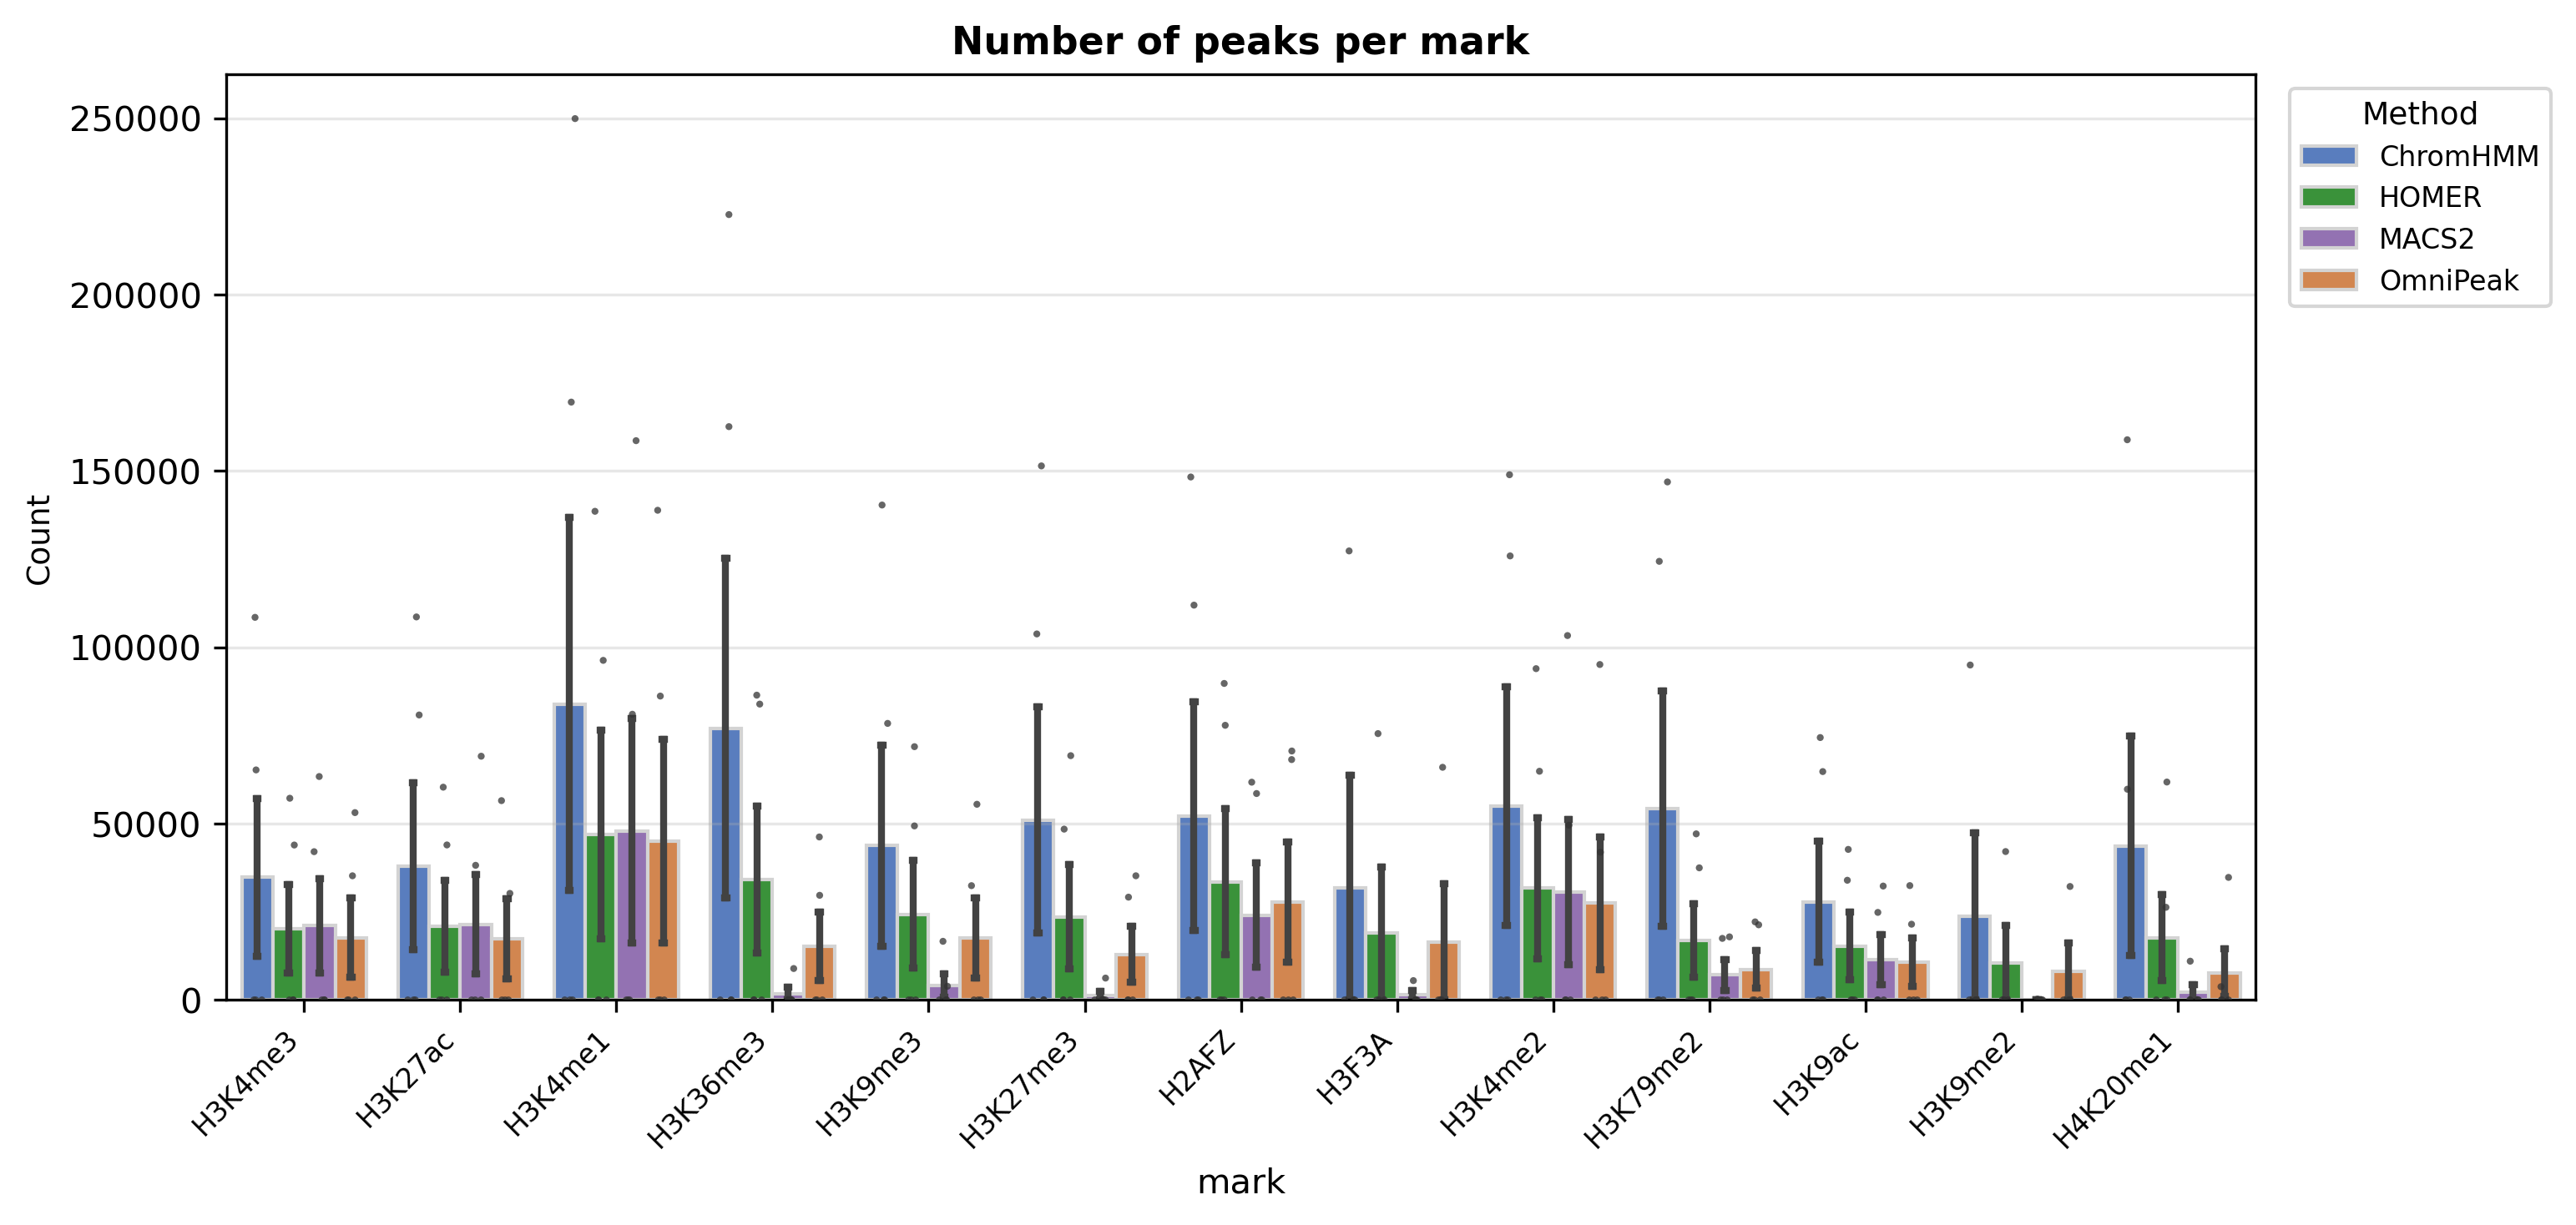

### peak_length.png


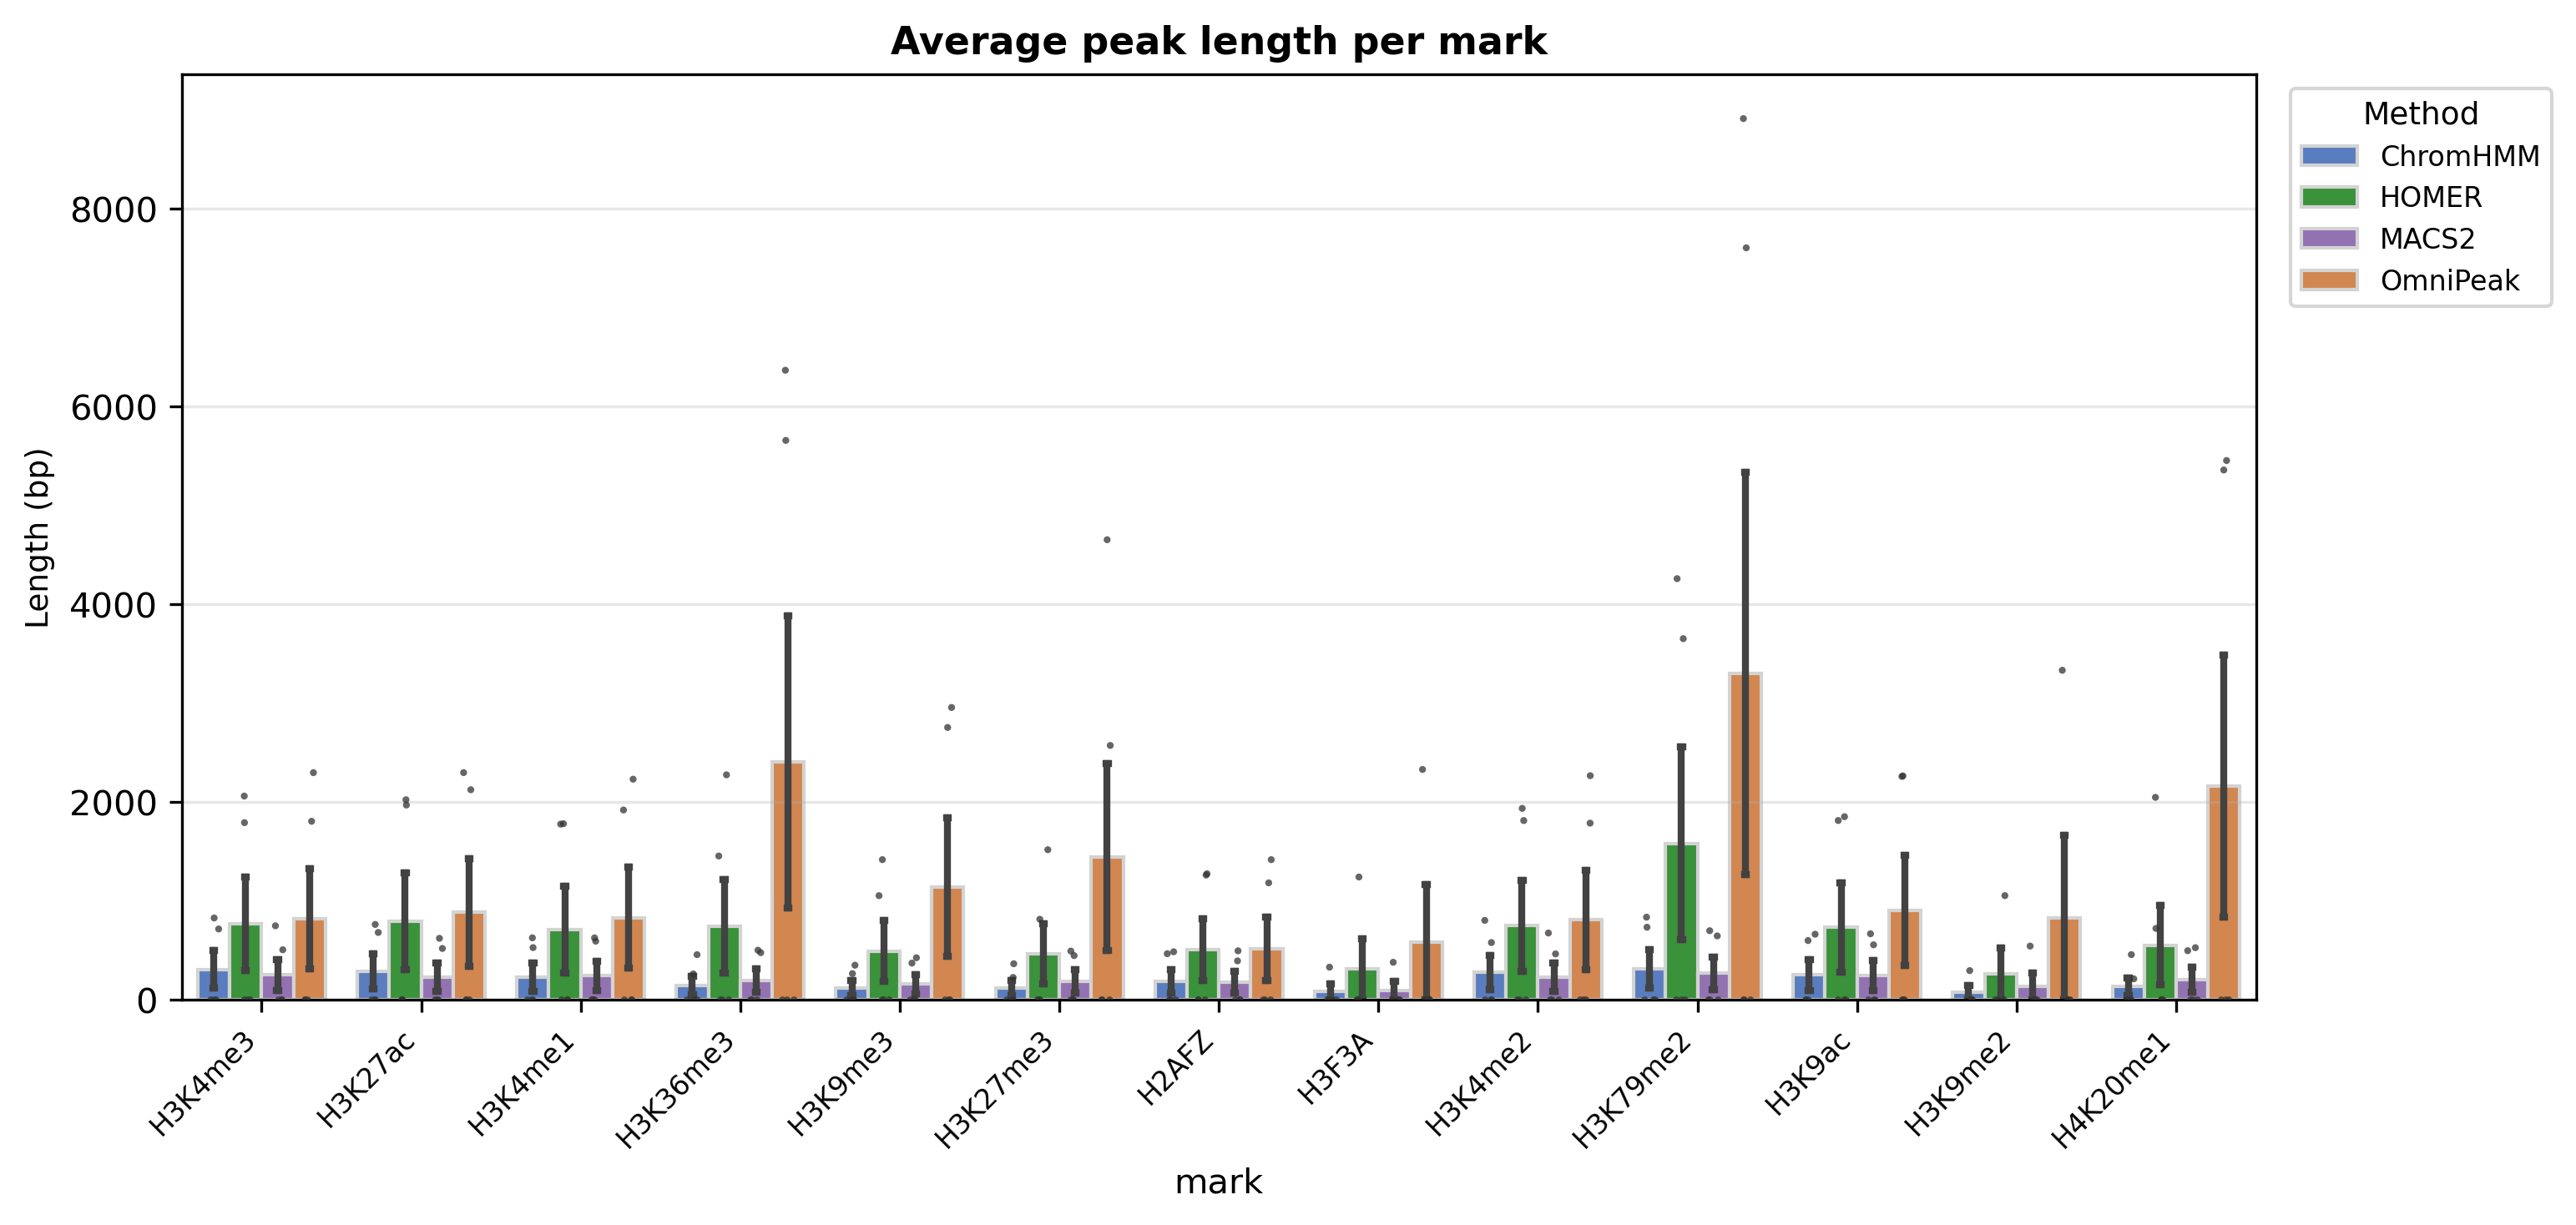

### n_segments.png


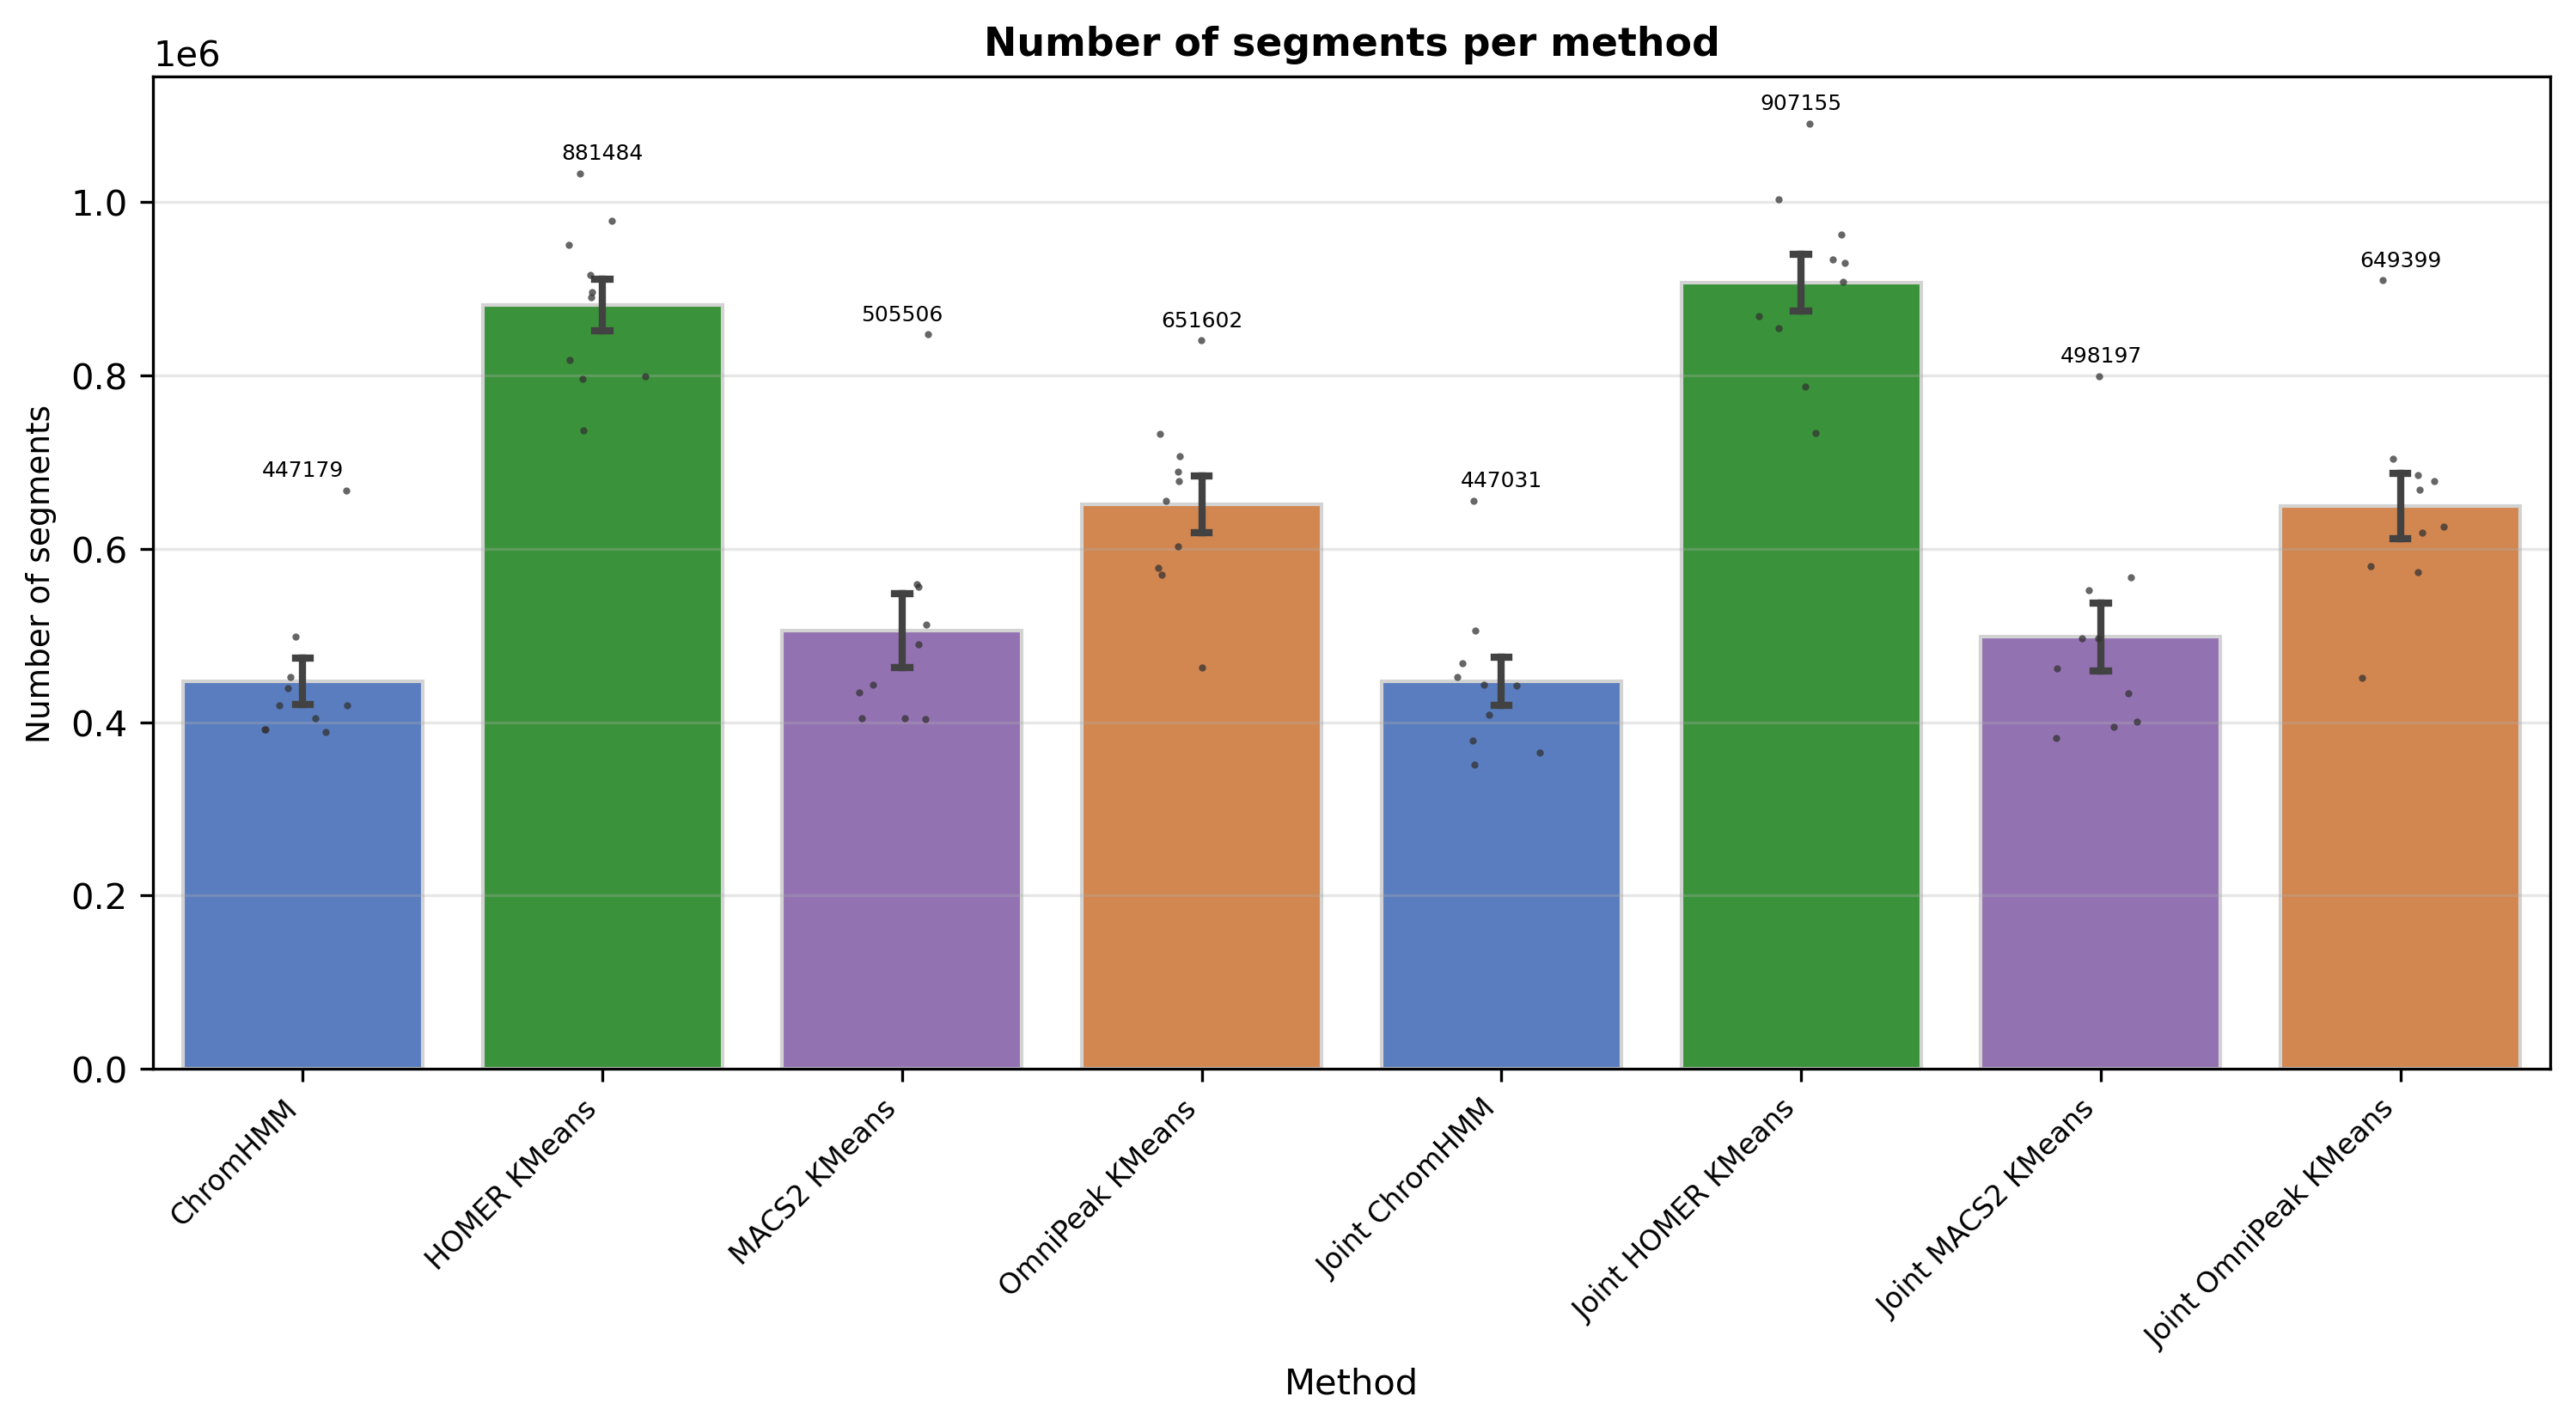

### entropy.png


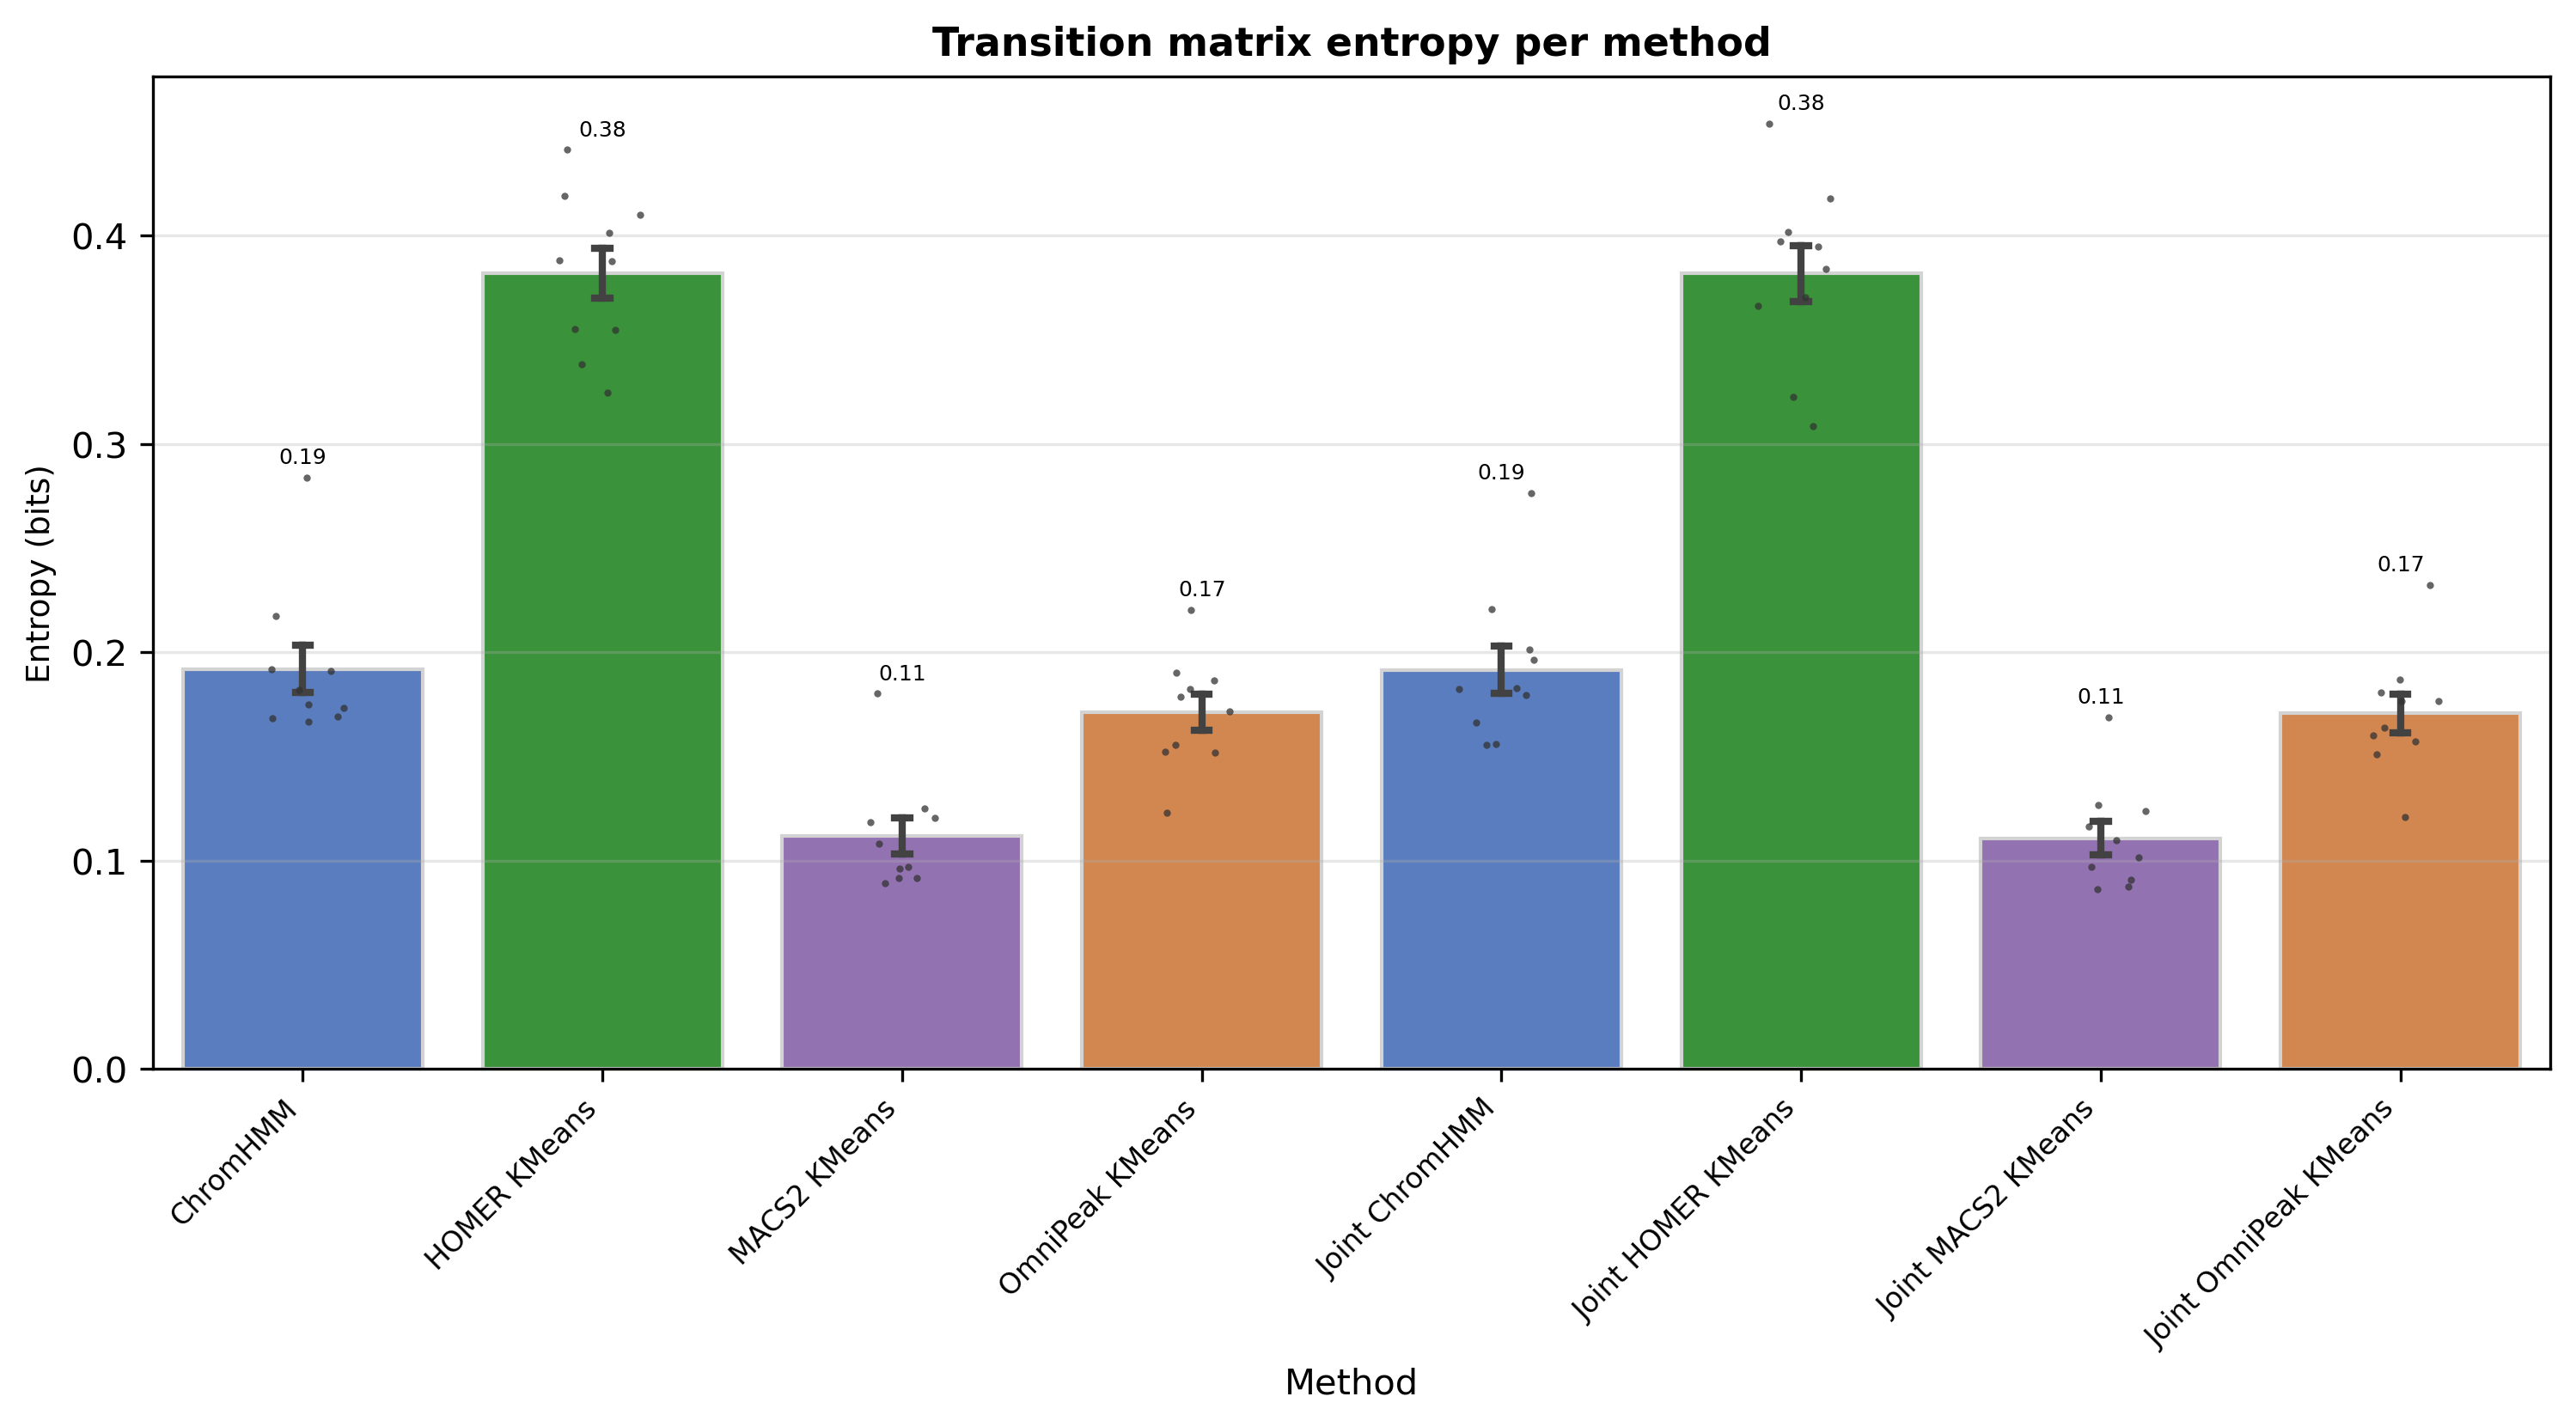

### replicate_jaccard.png


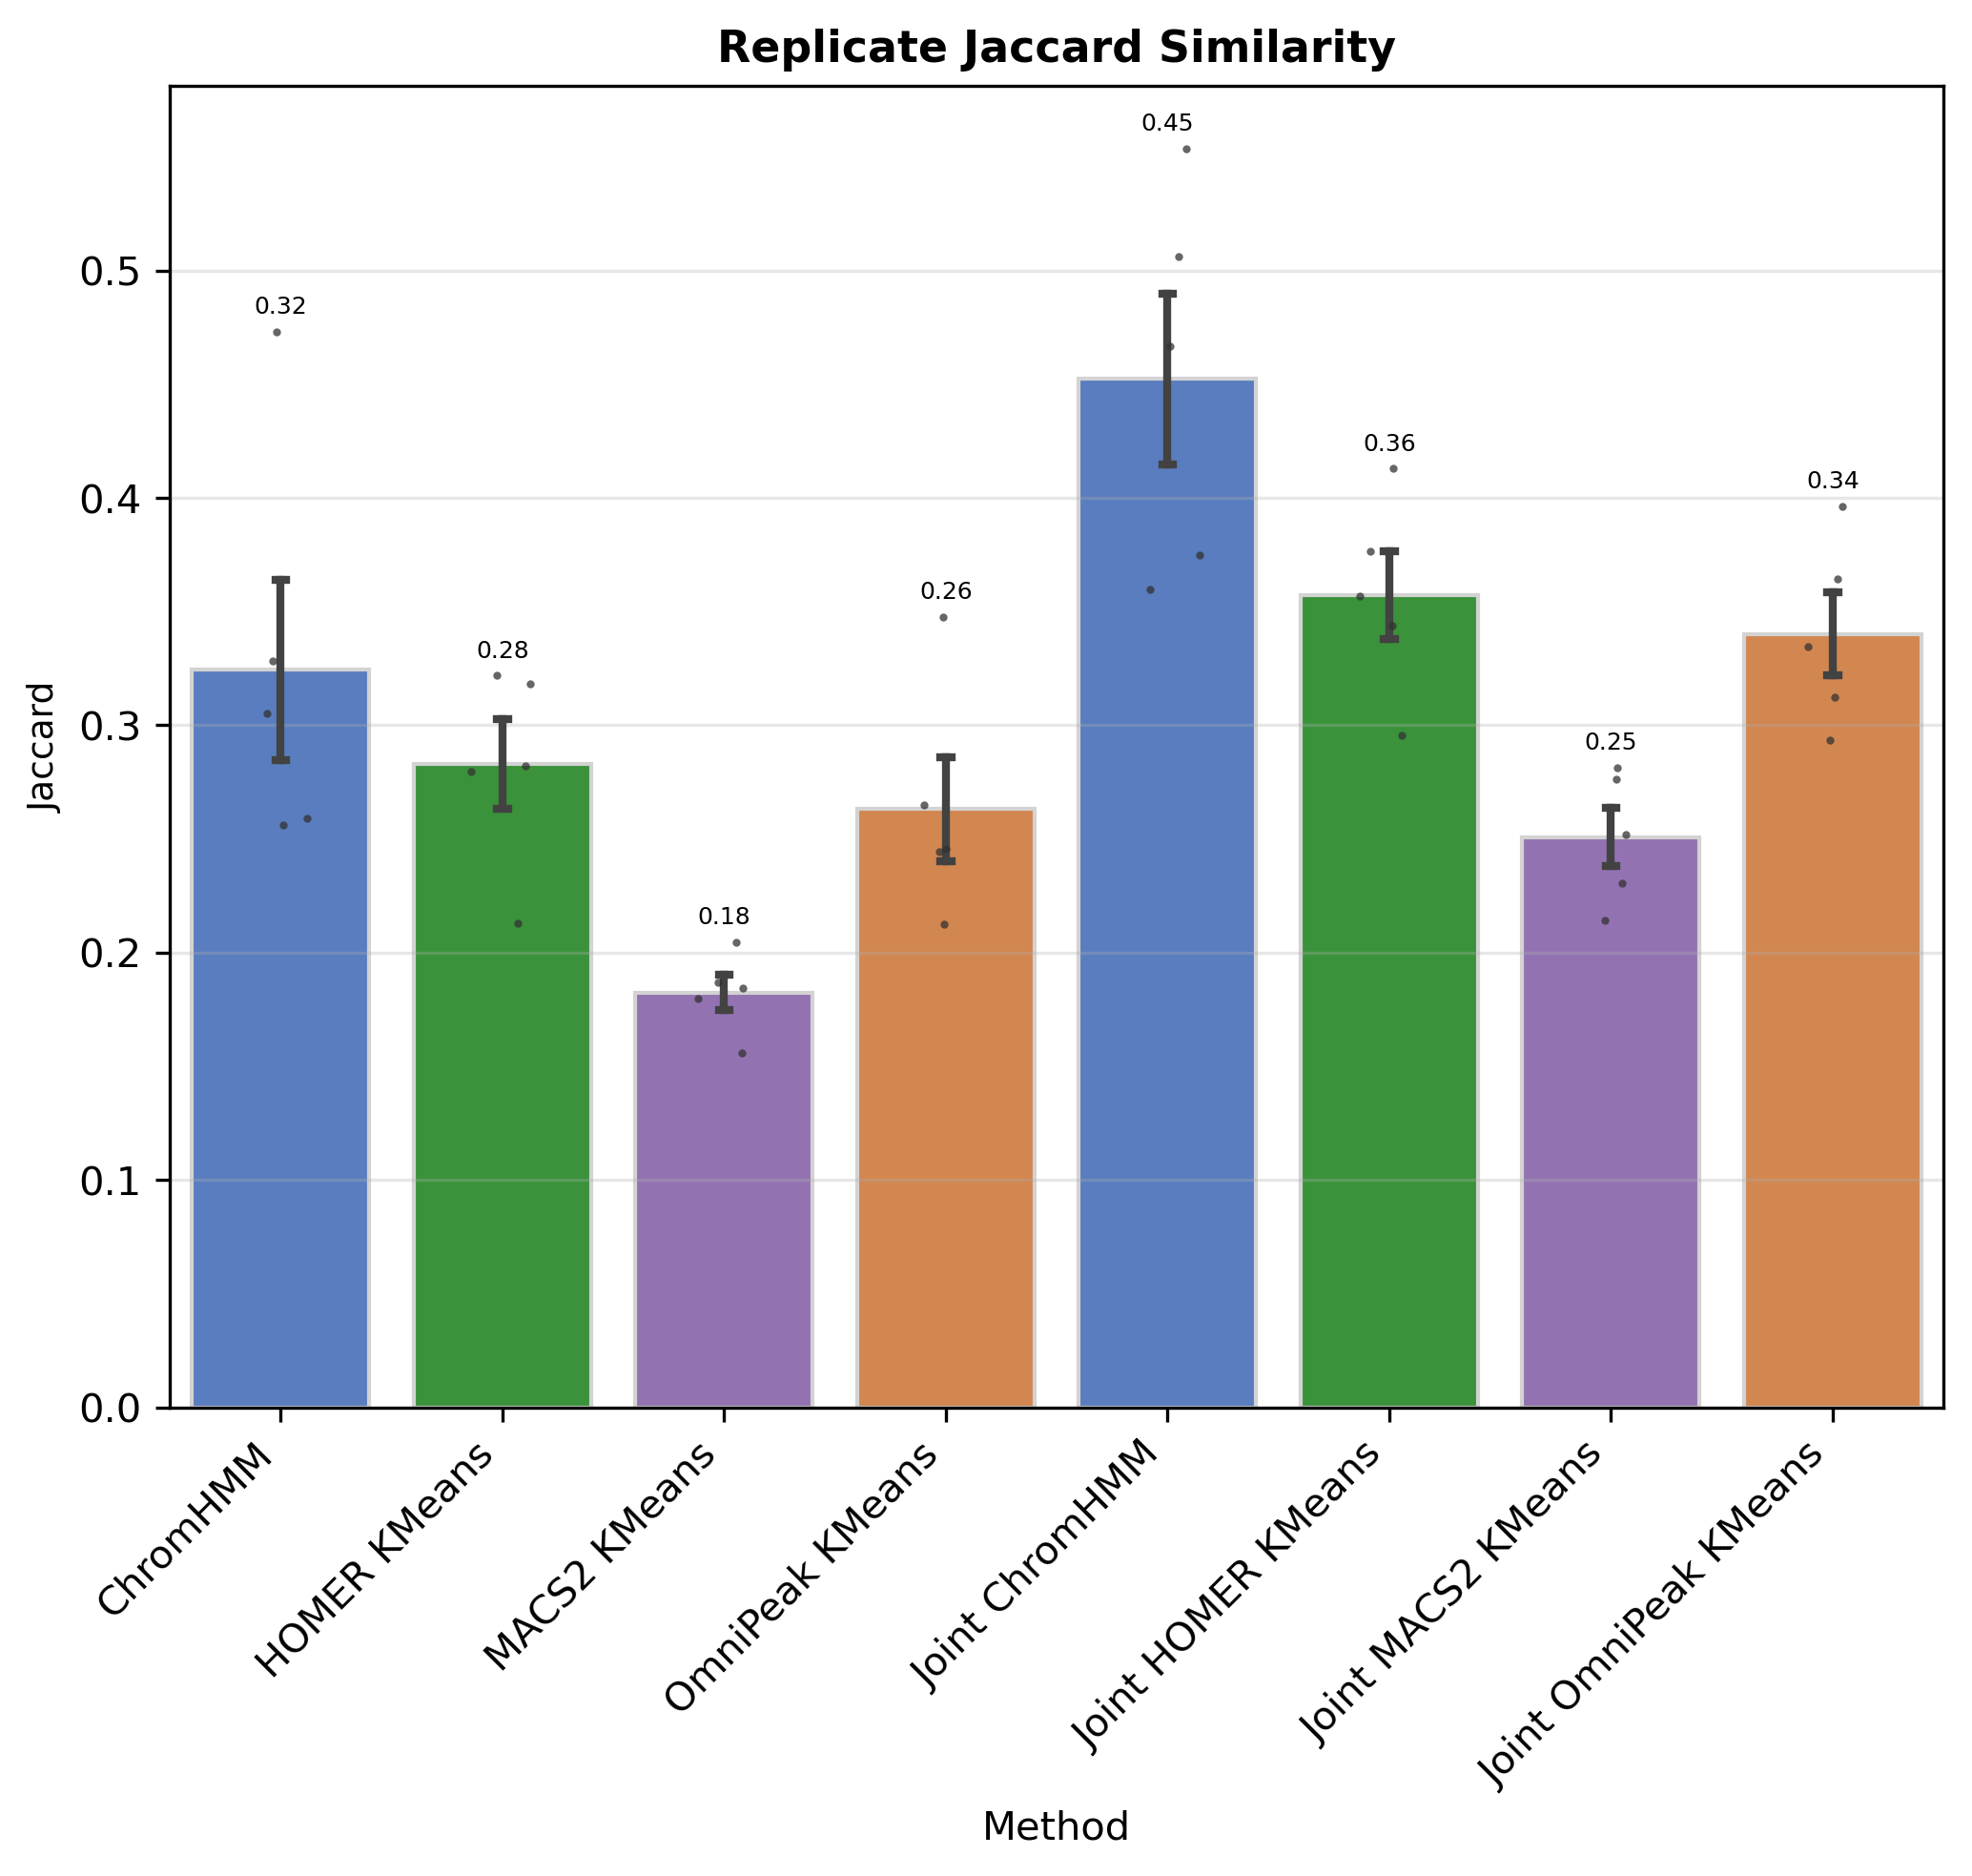

### replicate_kappa.png


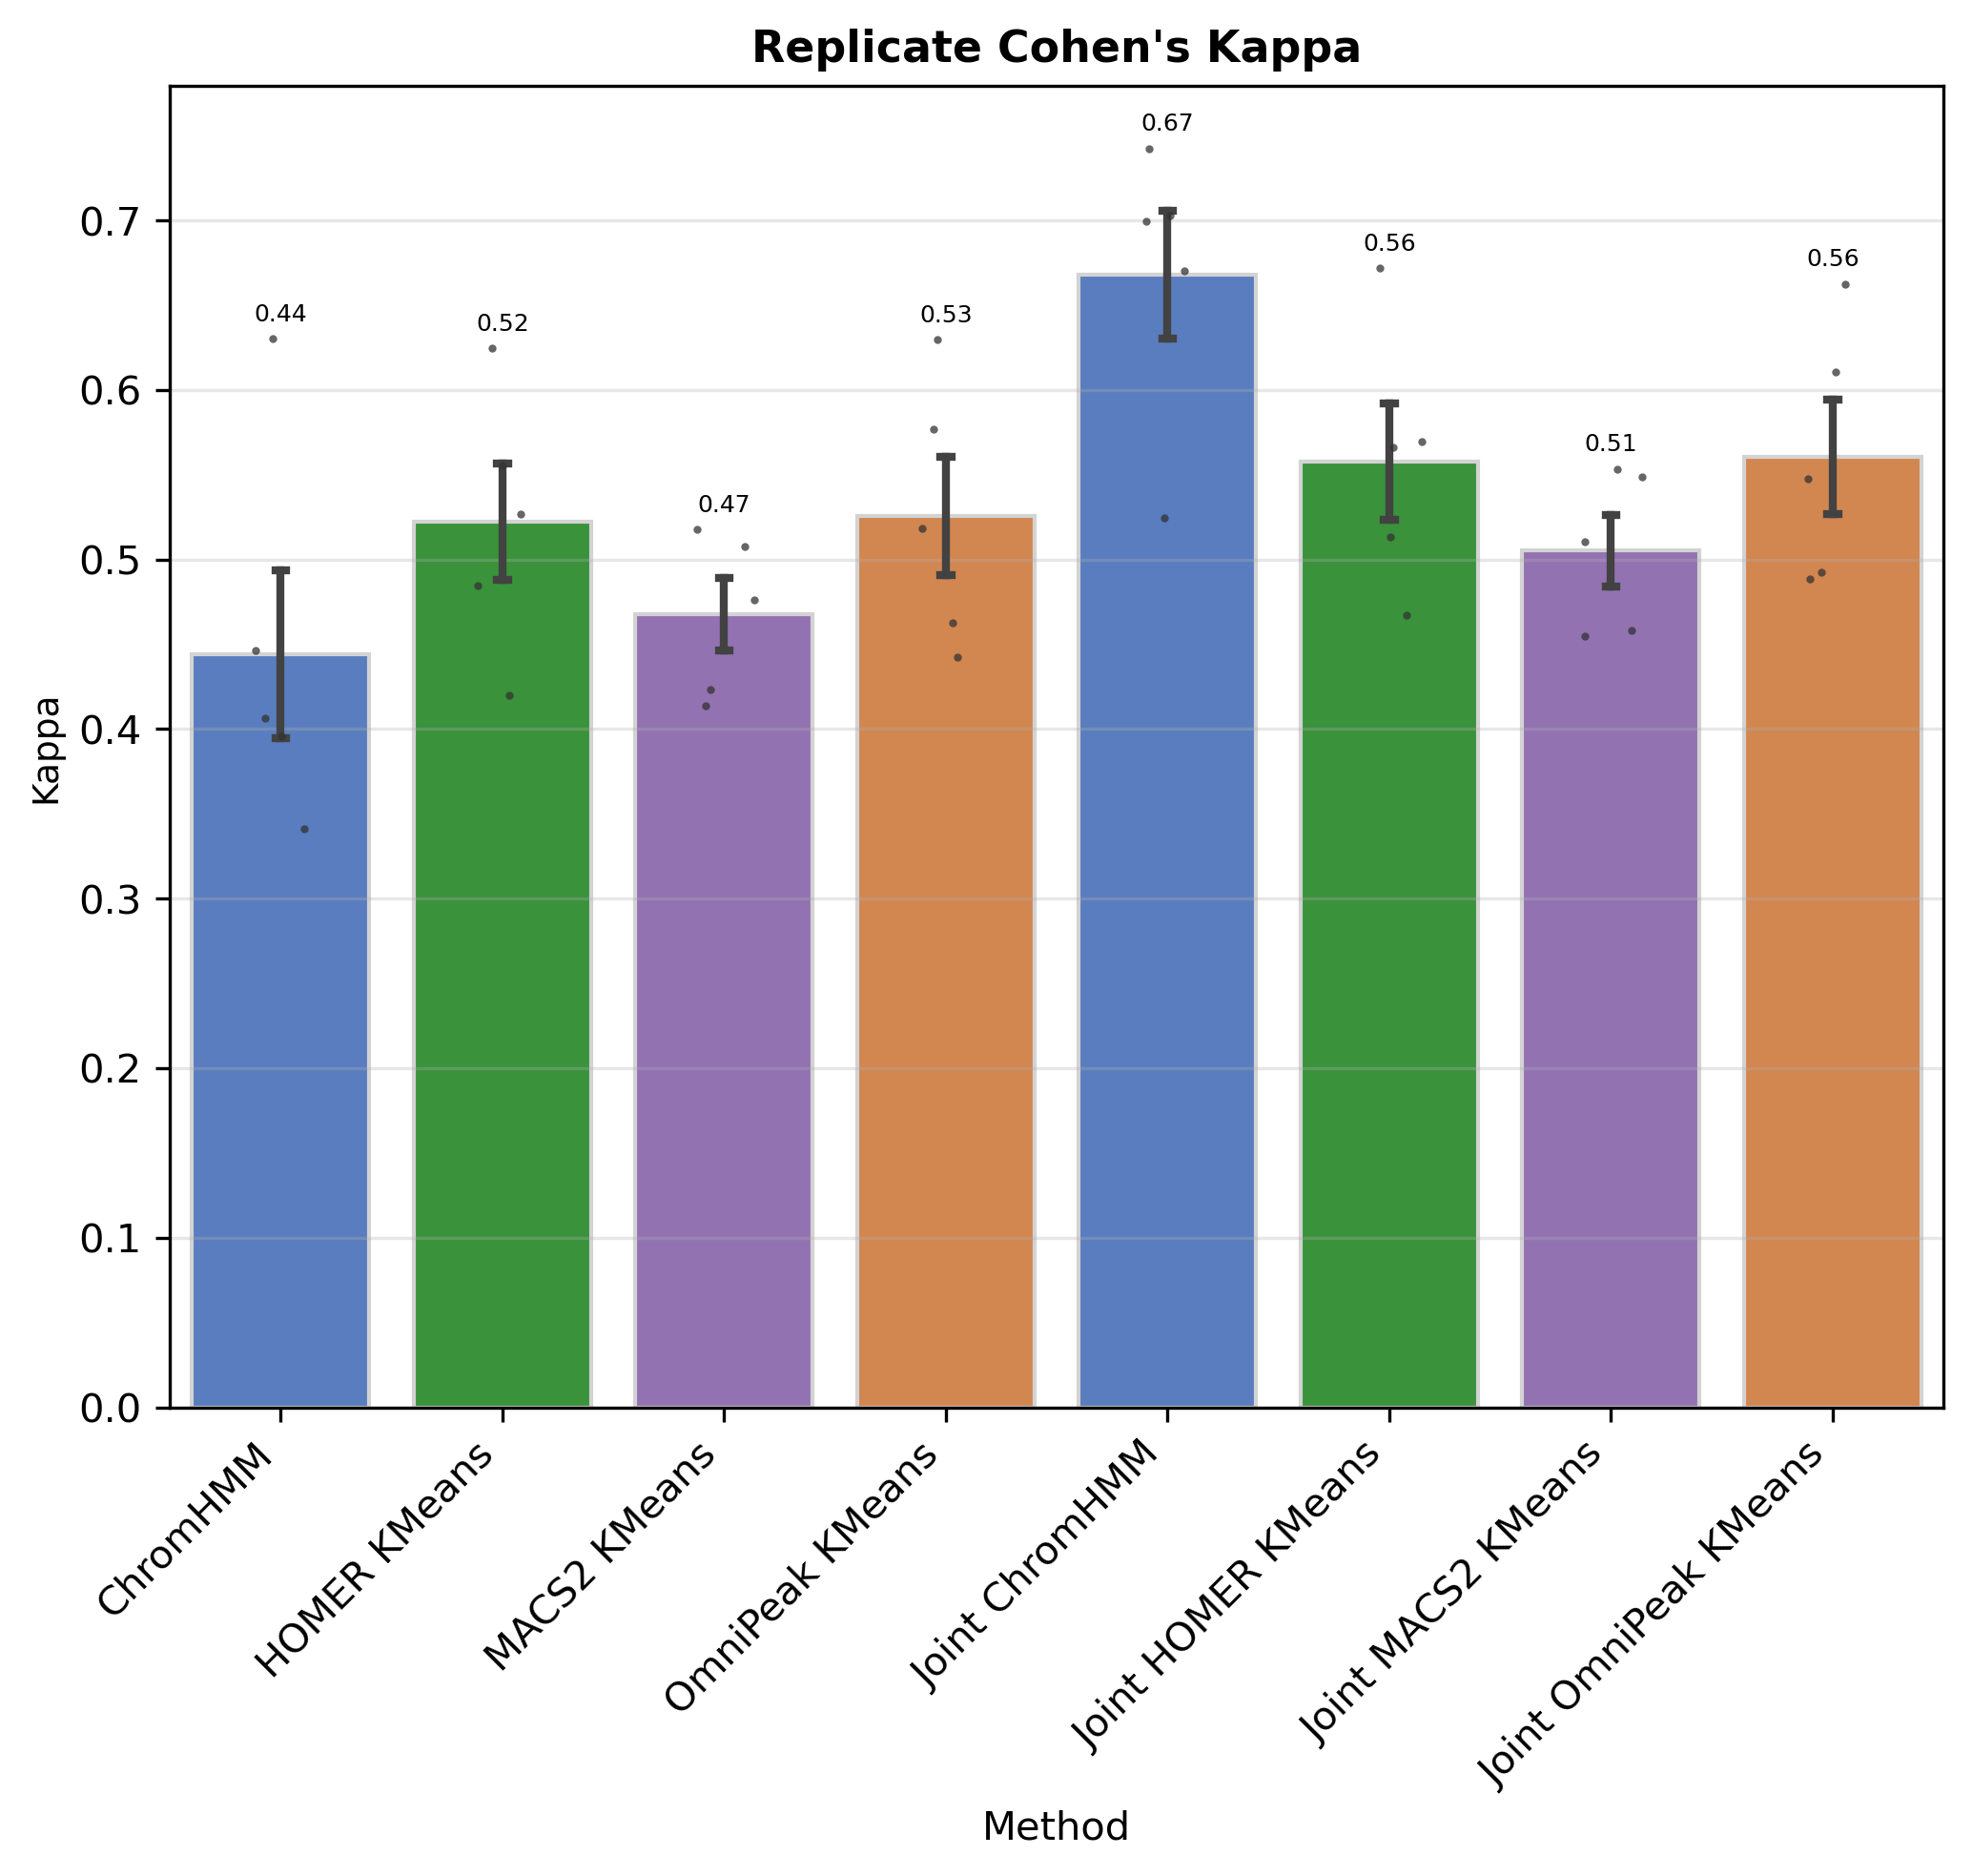

### joint_indiv_jaccard.png


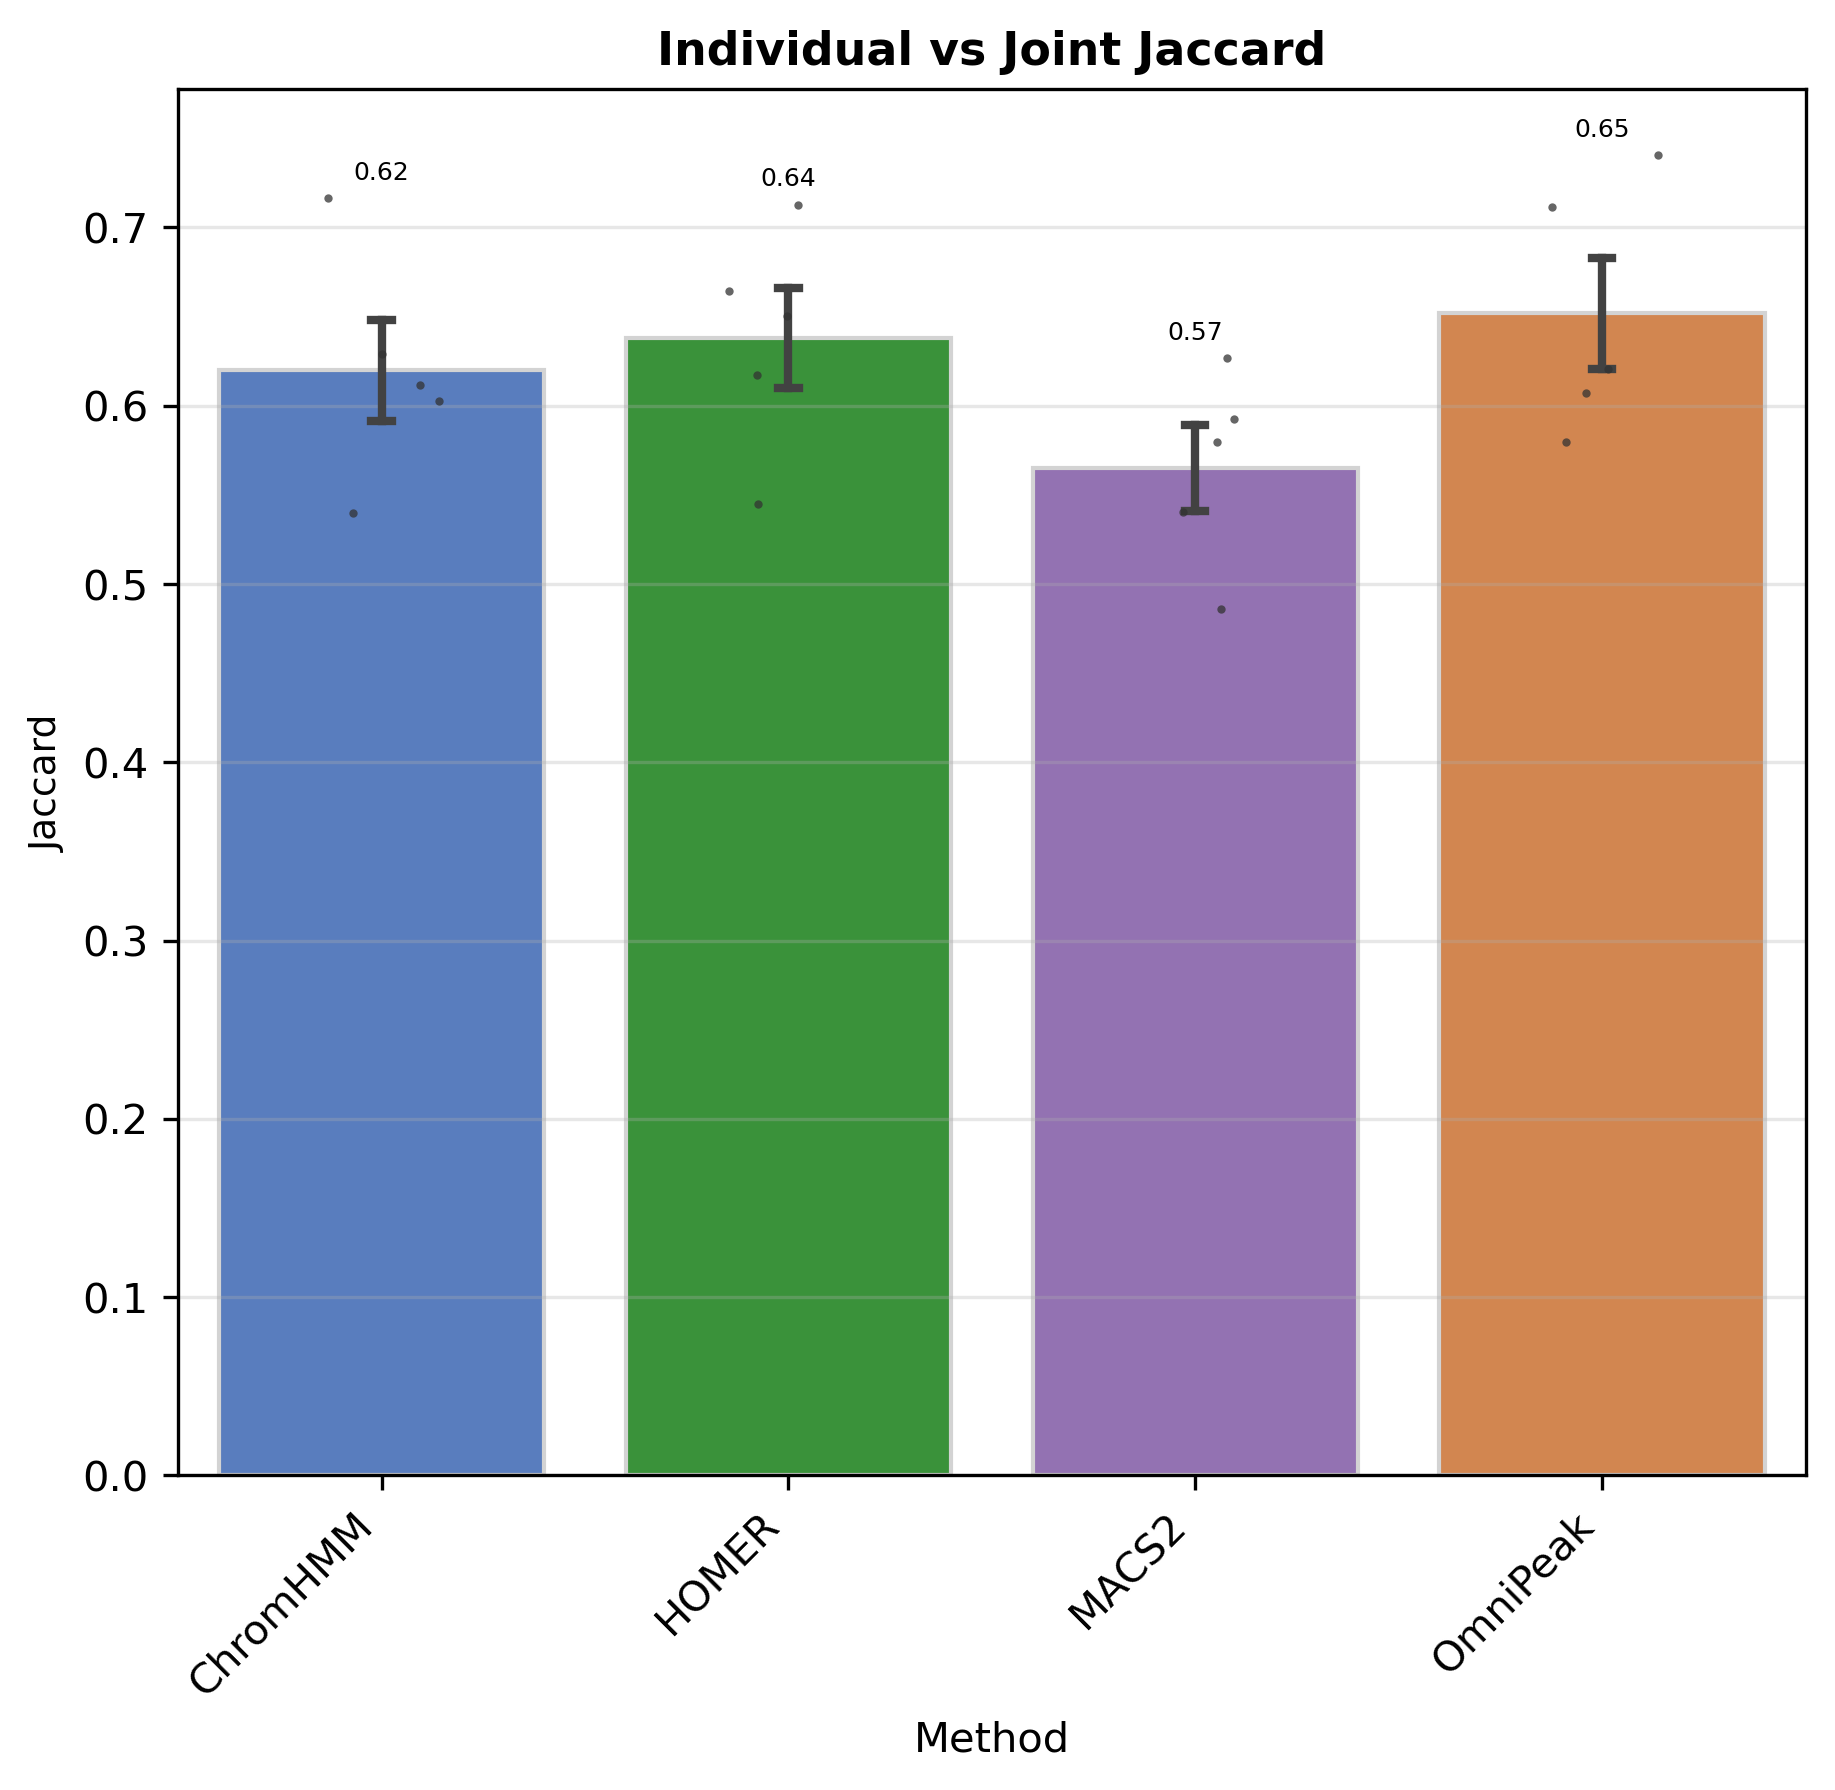

### joint_indiv_kappa.png


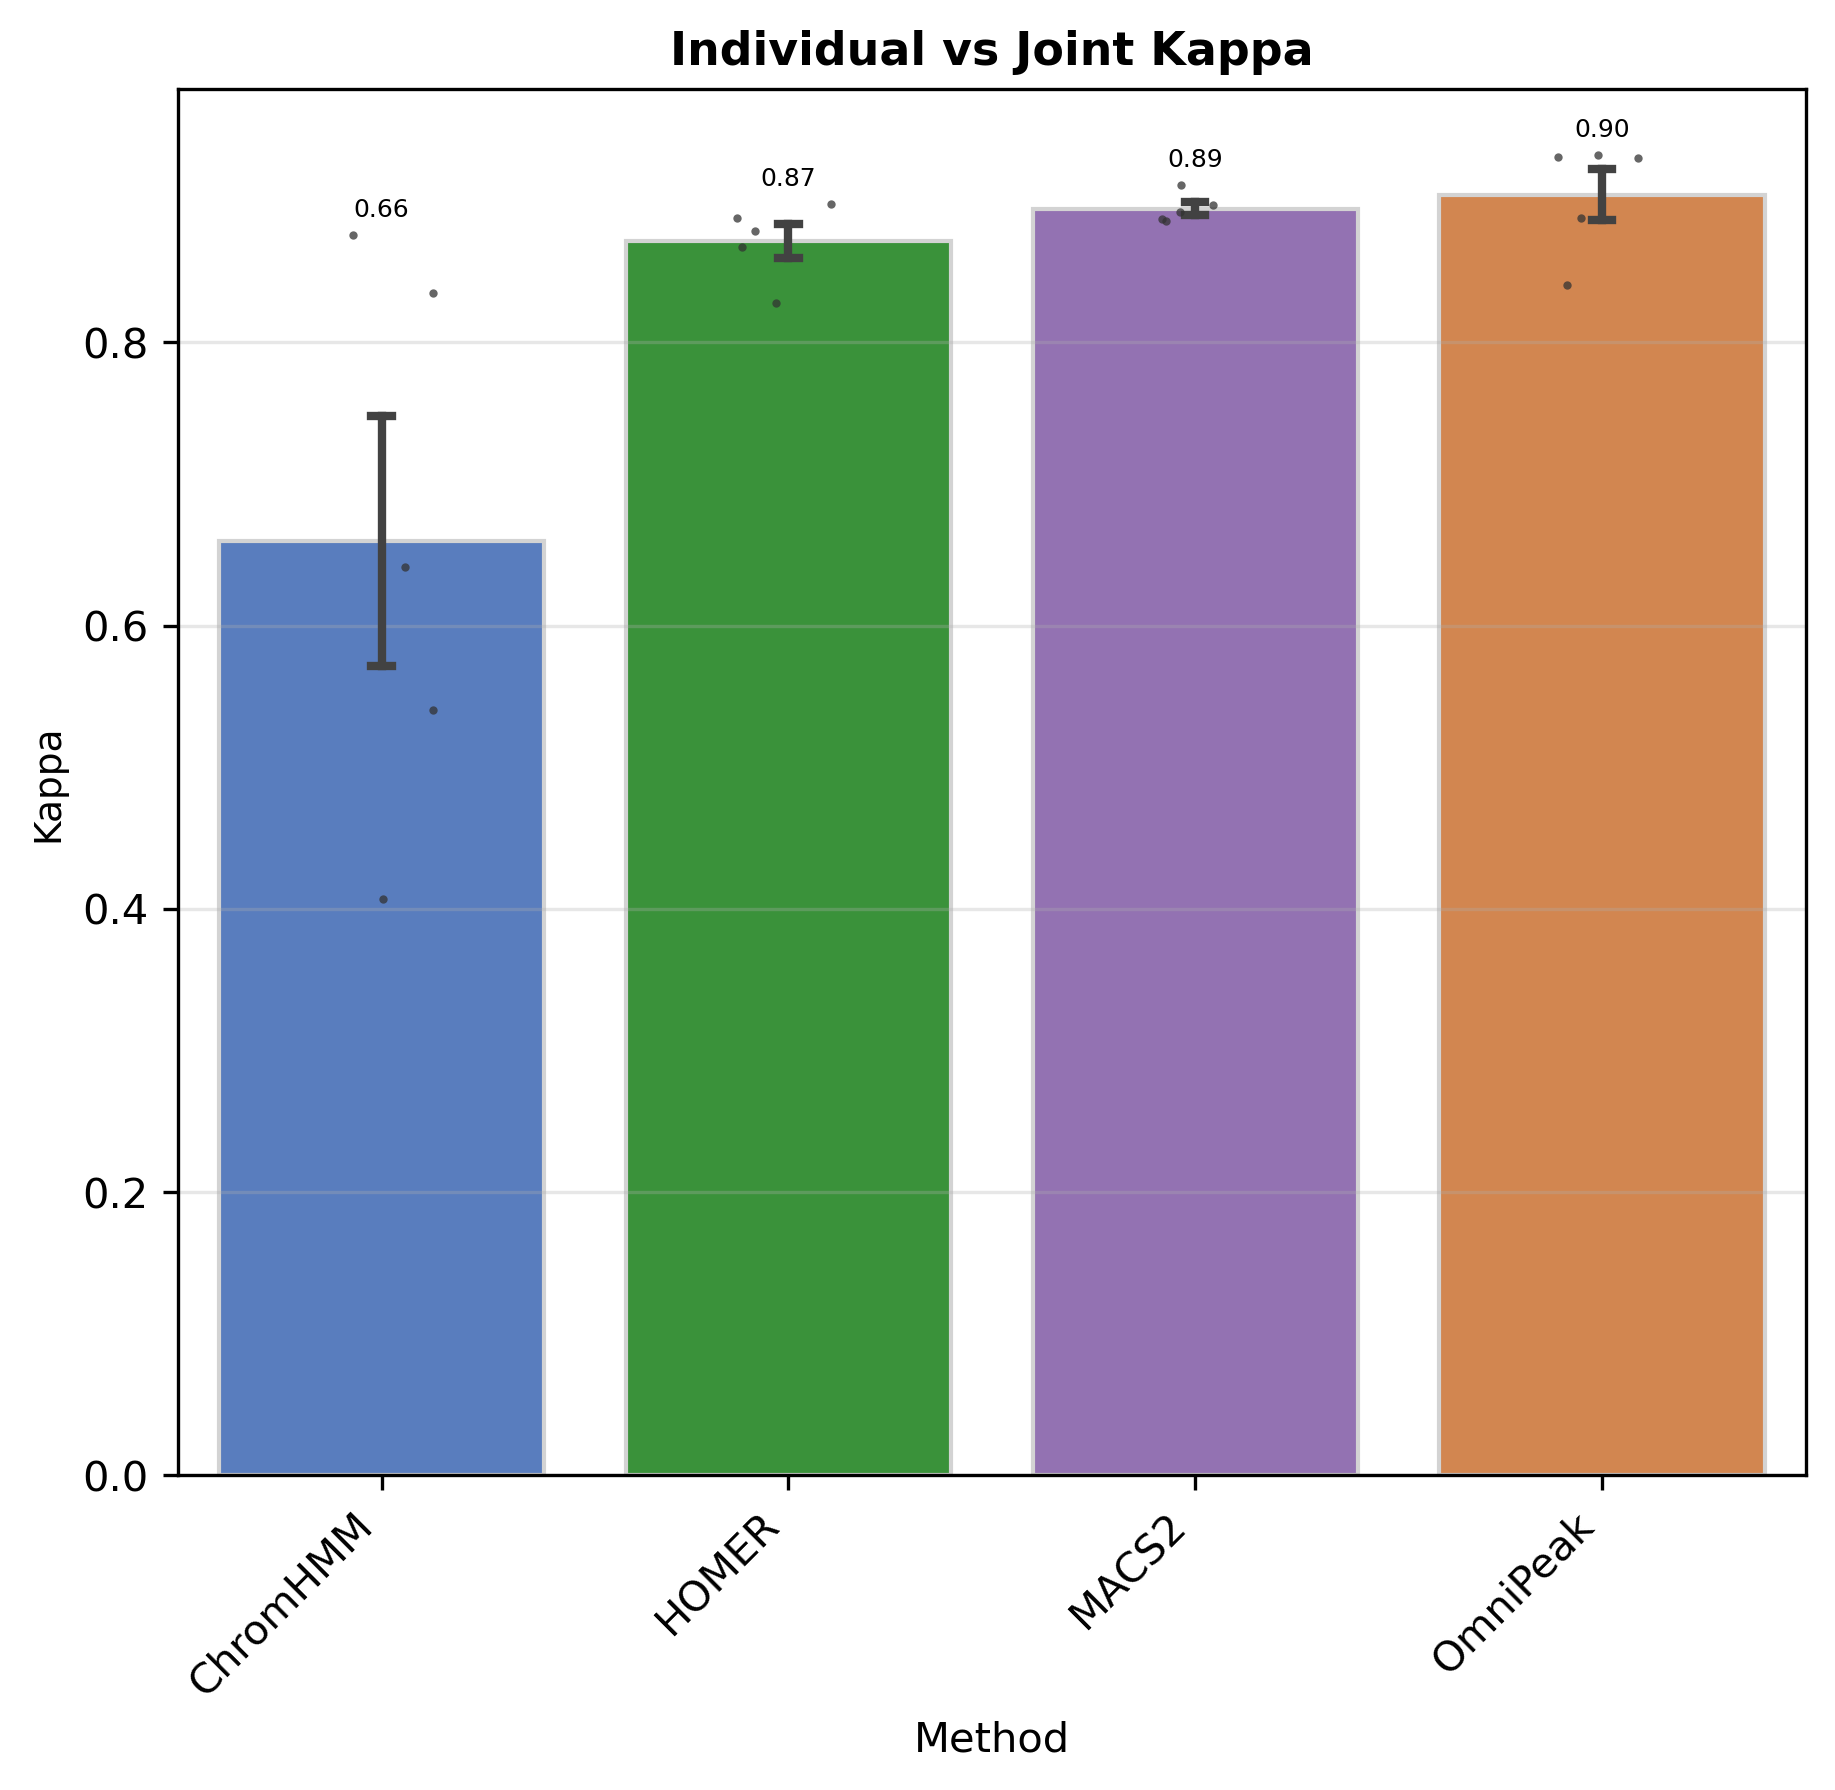

In [13]:
for img in ["n_peaks.png", "peak_length.png", "n_segments.png", "entropy.png",
            "replicate_jaccard.png", "replicate_kappa.png",
            "joint_indiv_jaccard.png", "joint_indiv_kappa.png"]:
    path = f"out/summary_plots/{img}"
    if os.path.exists(path):
        print(f"### {img}")
        display(Image(filename=path))

In [10]:

# # Display per-dataset results
# for ds in DATASETS:
#     ds_header_printed = False
#     for method_key, method_name in METHOD_LABELS:
#         outdir = f"out/{ds}/matched/{method_key}"
#         emissions_png = f"{outdir}/bin_emissions/state_emissions.png"
#         enrichment_png = f"{outdir}/enrichment/enrichment.png"
#
#         if os.path.exists(emissions_png) or os.path.exists(enrichment_png):
#             if not ds_header_printed:
#                 print(f"### Dataset: {ds}")
#                 ds_header_printed = True
#             print(f"#### Method: {method_name}")
#             if os.path.exists(emissions_png):
#                 display(Image(filename=emissions_png))
#             if os.path.exists(enrichment_png):
#                 display(Image(filename=enrichment_png))